# Ekstraksi Fitur TSFEL dan Perhitungan Manual pada Data Polutan Udara

Catatan ini adalah **bagian 1 dari 2** dari analisis data polutan udara Kecamatan Waru menggunakan library **TSFEL**. Bagian ini mencakup ekstraksi 68 fitur time series (domain statistical, temporal, spectral, dan fractal) untuk tiga polutan — **NO2, CO, dan SO2** — beserta konsep, rumus, dan pembuktian perhitungan manual untuk fitur bagian sendiri. Proses **K-Means Clustering** (penggabungan data ke database, evaluasi jumlah cluster, visualisasi PCA, dan implementasi workflow KNIME) dibahas terpisah pada notebook **bagian 2**.

Cakupan catatan ini meliputi:
1. Data preparation: deteksi outlier (metode IQR) dan imputasi missing value untuk ketiga polutan sekaligus, sebelum masuk ke ekstraksi fitur
2. Ekstraksi 68 fitur TSFEL per polutan
3. Konsep dasar, rumus, dan pembuktian perhitungan manual untuk fitur bagian sendiri (`fundamental_frequency`, `hist_mode`)
4. Deskripsi lengkap 68 fitur TSFEL berdasarkan 4 domain resmi (Statistical, Temporal, Spectral, Fractal)

# Ekstraksi 68 Fitur Time Series Pada NO2, CO, dan SO2 Menggunakan Library TSFEL

## 1. Instalasi Library

In [ ]:
!pip install tsfel

Penjelasan kode di atas adalah sebagai berikut.

- Baris `!pip install tsfel` memasang pustaka `tsfel` (*Time Series Feature Extraction Library*), yang menyediakan kumpulan fungsi siap pakai untuk menghitung berbagai fitur statistik, spektral, temporal, dan fraktal dari sinyal deret waktu. Pustaka ini dipasang satu kali di awal karena dipakai berulang pada ketiga tahap ekstraksi (NO2, CO, SO2) berikutnya.

## 2. Data Preparation: Deteksi Outlier dan Imputasi Missing Value

Sebelum sinyal CO, NO2, dan SO2 dimasukkan ke proses ekstraksi fitur, ketiganya perlu dibersihkan dulu dari outlier dan nilai kosong, karena TSFEL tidak bisa mengolah data yang masih mengandung `NaN`. Tahap ini sengaja dipisahkan dari proses ekstraksi fitur (bagian 3–5) agar alurnya lebih jelas: bersihkan dulu ketiga polutan sekaligus di sini, baru masuk ke ekstraksi fitur satu per satu pada bagian berikutnya.

Alur pembersihan pada tiap polutan mengikuti tiga langkah yang sama:
1. **Paksa numerik** — kolom polutan dipaksa bertipe numerik (`pd.to_numeric(..., errors="coerce")`); nilai yang tidak valid otomatis menjadi `NaN`.
2. **Deteksi outlier (metode IQR)** — nilai di luar rentang `[Q1 - 1,5×IQR, Q3 + 1,5×IQR]` ditandai sebagai outlier, lalu diubah menjadi `NaN` (bukan dihapus barisnya) agar deret tanggal tetap utuh dan ikut ditangani pada langkah imputasi.
3. **Imputasi berbasis waktu** — nilai kosong diisi dengan `interpolate(method="time")`, lalu sisa nilai kosong di ujung awal/akhir data (yang tidak bisa diinterpolasi) diisi dengan `ffill()` dan `bfill()`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

POLUTAN_TARGET = ["CO", "NO2", "SO2"]

df = pd.read_csv("data_polutan_waru.csv")
df["tanggal"] = pd.to_datetime(df["tanggal"])
df = df.sort_values("tanggal").reset_index(drop=True)

# Menyimpan data asli (sebelum penanganan) untuk keperluan perbandingan/visualisasi
df_awal = df.copy()

sinyal_bersih = {}
ringkasan_missing_list = []
batas_iqr = {}
outliers_iqr_dict = {}

for pol in POLUTAN_TARGET:
    df[pol] = pd.to_numeric(df[pol], errors="coerce")

    # Missing value pada data awal (sebelum outlier ditangani)
    n_missing_awal = df[pol].isna().sum()
    persen_missing_awal = (n_missing_awal / len(df)) * 100

    # Deteksi outlier dengan metode IQR
    q1, q3 = df[pol].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    kondisi_outlier = (df[pol] < lower) | (df[pol] > upper)
    outliers_iqr_dict[pol] = df.loc[kondisi_outlier, ["tanggal", pol]].copy()
    jumlah_outlier = kondisi_outlier.sum()
    batas_iqr[pol] = {"lower": lower, "upper": upper}

    # Outlier dijadikan NaN agar ikut ditangani pada tahap imputasi
    df.loc[kondisi_outlier, pol] = np.nan

    # Missing value setelah deteksi outlier
    n_missing_setelah_outlier = df[pol].isna().sum()
    persen_missing_setelah_outlier = (n_missing_setelah_outlier / len(df)) * 100

    # Imputasi berdasarkan waktu (time-based interpolation), sisa di ujung data diisi ffill/bfill
    hasil_interpolasi = (
        df.set_index("tanggal")[[pol]]
        .interpolate(method="time")
        .ffill()
        .bfill()
    )

    n_missing_sesudah = hasil_interpolasi[pol].isna().sum()
    sinyal_bersih[pol] = hasil_interpolasi[pol].astype(float).values

    ringkasan_missing_list.append({
        "polutan": pol,
        "missing_awal": n_missing_awal,
        "persen_awal": persen_missing_awal,
        "jumlah_outlier": jumlah_outlier,
        "missing_setelah_outlier": n_missing_setelah_outlier,
        "persen_setelah_outlier": persen_missing_setelah_outlier,
        "missing_sesudah_imputasi": n_missing_sesudah,
    })

    print(f"\n===== {pol} =====")
    print(f"Missing value awal               : {n_missing_awal} ({persen_missing_awal:.2f}%)")
    print(f"Jumlah outlier (IQR)              : {jumlah_outlier}")
    print(f"Missing setelah deteksi outlier    : {n_missing_setelah_outlier} ({persen_missing_setelah_outlier:.2f}%)")
    print(f"Missing setelah imputasi           : {n_missing_sesudah} ({(n_missing_sesudah/len(df))*100:.2f}%)")

# Data hasil penanganan lengkap, dengan kolom tanggal yang tetap sama seperti data asli
df_setelah = df_awal.copy()
for pol in POLUTAN_TARGET:
    df_setelah[pol] = sinyal_bersih[pol]

print("\nPreprocessing selesai untuk:", POLUTAN_TARGET)


===== CO =====
Missing value awal               : 141 (38.52%)
Jumlah outlier (IQR)              : 4
Missing setelah deteksi outlier    : 145 (39.62%)
Missing setelah imputasi           : 0 (0.00%)

===== NO2 =====
Missing value awal               : 173 (47.27%)
Jumlah outlier (IQR)              : 4
Missing setelah deteksi outlier    : 177 (48.36%)
Missing setelah imputasi           : 0 (0.00%)

===== SO2 =====
Missing value awal               : 149 (40.71%)
Jumlah outlier (IQR)              : 14
Missing setelah deteksi outlier    : 163 (44.54%)
Missing setelah imputasi           : 0 (0.00%)

Preprocessing selesai untuk: ['CO', 'NO2', 'SO2']


Penjelasan kode di atas adalah sebagai berikut.

- `data_polutan_waru.csv` dibaca, kolom `tanggal` dijadikan datetime dan diurutkan; `df_awal` menyimpan kondisi sebelum penanganan sebagai pembanding.
- Untuk tiap polutan (CO, NO2, SO2) dijalankan tiga langkah berurutan: paksa numerik → deteksi outlier (IQR) → imputasi berbasis waktu.
- `n_missing_awal` dihitung sebelum deteksi outlier, `n_missing_setelah_outlier` sesudahnya, sehingga selisihnya menunjukkan jumlah outlier yang diubah menjadi `NaN`.
- Batas IQR dan daftar outlier disimpan per polutan untuk dipakai ulang pada visualisasi (2.2) tanpa hitung ulang.
- `sinyal_bersih` (366 nilai per polutan, 0 missing) inilah yang dipakai pada ekstraksi fitur (bagian 3–5) dan perhitungan manual (bagian 7).
- `df_setelah` menggabungkan hasil bersih ketiga polutan untuk visualisasi pada bagian 2.3.

### 2.1 Ringkasan Missing Value Sebelum dan Sesudah Penanganan

In [ ]:
ringkasan_missing = pd.DataFrame(ringkasan_missing_list)
display(ringkasan_missing)

,polutan,missing_awal,persen_awal,jumlah_outlier,missing_setelah_outlier,persen_setelah_outlier,missing_sesudah_imputasi
0,CO,141,38.524590,4,145,39.617486,0
1,NO2,173,47.267760,4,177,48.360656,0
2,SO2,149,40.710383,14,163,44.535519,0


Penjelasan kode di atas adalah sebagai berikut.

- `ringkasan_missing_list` (diisi pada perulangan bagian 2) diubah menjadi `DataFrame` agar jumlah missing value dan outlier tiap polutan bisa dilihat dalam satu tabel.
- Tabel ini merangkum tiga tahap: `missing_awal` (sebelum outlier ditangani), `missing_setelah_outlier` (setelah outlier diubah menjadi `NaN`, sehingga jumlahnya sedikit lebih besar dari `missing_awal`), dan `missing_sesudah_imputasi` (selalu 0 untuk ketiga polutan, karena `interpolate` + `ffill`/`bfill` mengisi seluruh nilai kosong).
- SO2 memiliki jumlah outlier terbanyak (14 dari 366 hari), diikuti NO2 dan CO (masing-masing 4), sehingga persentase missing value SO2 naik paling besar (dari 40,71% menjadi 44,54%) akibat penambahan outlier sebagai `NaN`.

### 2.2 Perbandingan Data Sebelum dan Sesudah Deteksi Outlier

Kode berikut membandingkan data tiap polutan sebelum dan sesudah nilai outlier ditangani. Grafik "sebelum" menampilkan nilai outlier yang ditandai (titik merah) beserta batas bawah/atas IQR, sedangkan grafik "sesudah" menunjukkan data setelah outlier diubah menjadi `NaN` (garis terputus pada titik outlier).

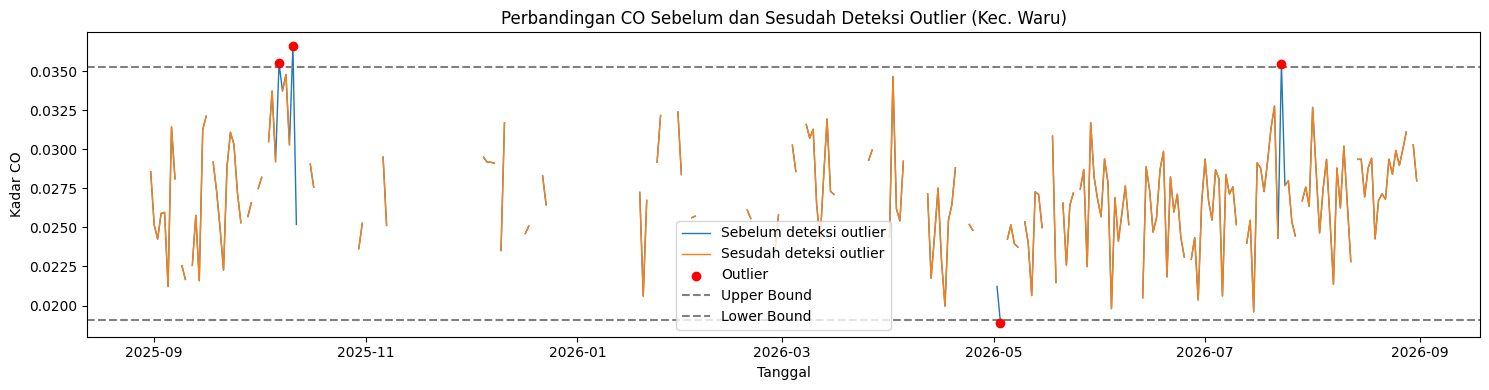

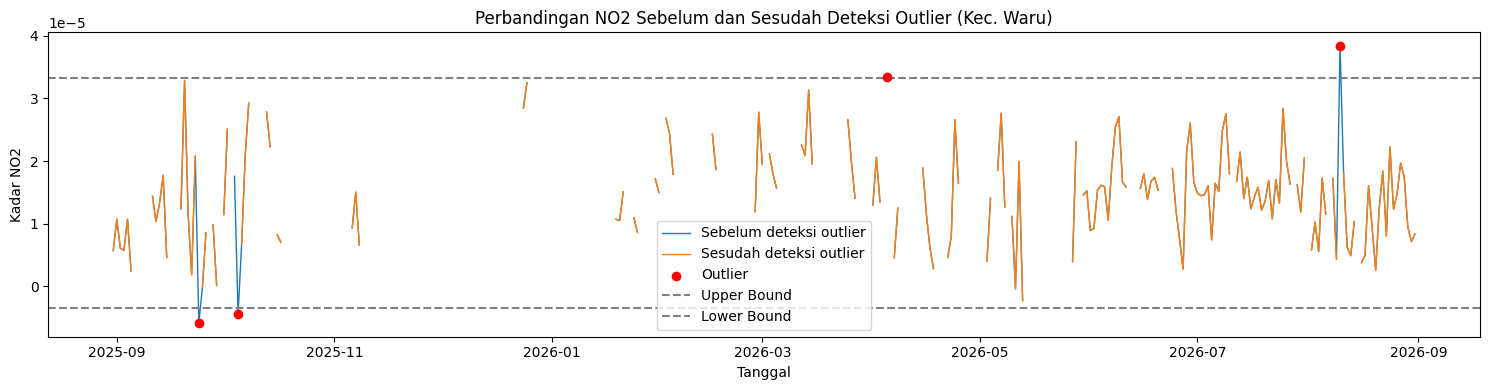

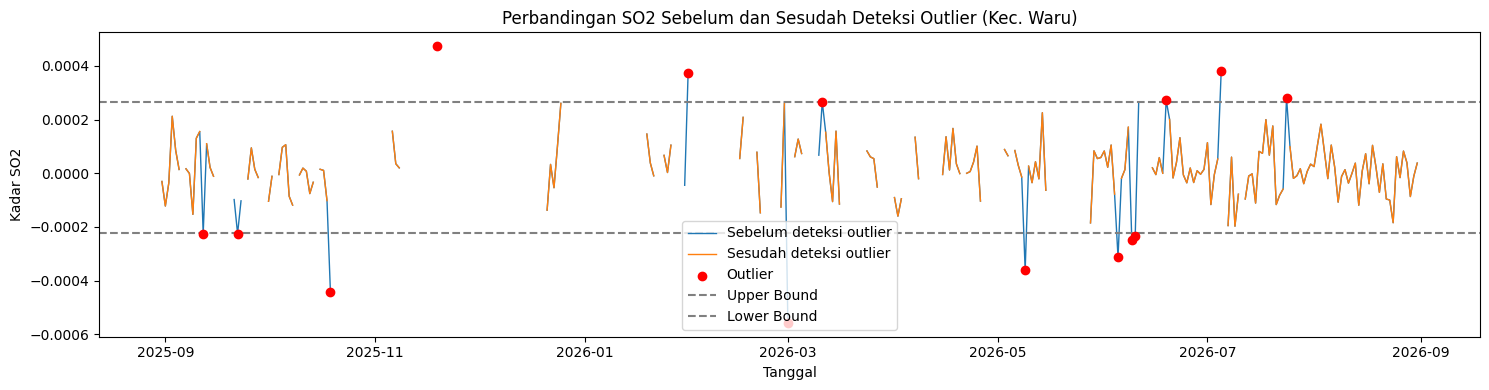

In [ ]:
for pol in POLUTAN_TARGET:
    data_sebelum = df_awal.copy()
    data_sebelum[pol] = pd.to_numeric(data_sebelum[pol], errors="coerce")

    lower_bound = batas_iqr[pol]["lower"]
    upper_bound = batas_iqr[pol]["upper"]

    kondisi_outlier = (
        (data_sebelum[pol] < lower_bound) |
        (data_sebelum[pol] > upper_bound)
    )

    data_setelah = data_sebelum.copy()
    data_setelah.loc[kondisi_outlier, pol] = np.nan

    plt.figure(figsize=(15, 4))
    plt.plot(data_sebelum["tanggal"], data_sebelum[pol], label="Sebelum deteksi outlier", linewidth=1)
    plt.plot(data_setelah["tanggal"], data_setelah[pol], label="Sesudah deteksi outlier", linewidth=1)
    plt.scatter(
        data_sebelum.loc[kondisi_outlier, "tanggal"],
        data_sebelum.loc[kondisi_outlier, pol],
        label="Outlier", marker="o", color="red", zorder=5
    )
    plt.axhline(upper_bound, linestyle="dashed", color="gray", label="Upper Bound")
    plt.axhline(lower_bound, linestyle="dashed", color="gray", label="Lower Bound")
    plt.title(f"Perbandingan {pol} Sebelum dan Sesudah Deteksi Outlier (Kec. Waru)")
    plt.xlabel("Tanggal")
    plt.ylabel(f"Kadar {pol}")
    plt.legend()
    plt.tight_layout()
    plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- Perulangan dilakukan untuk CO, NO2, dan SO2 agar ketiga polutan divisualisasikan dengan cara yang sama.
- `batas_iqr[pol]` (disimpan pada bagian 2) dipakai langsung sebagai batas bawah/atas pada grafik, tanpa menghitung ulang IQR.
- Titik merah menandai nilai yang terdeteksi sebagai outlier; setelah diubah menjadi `NaN`, titik tersebut terlihat sebagai celah pada garis "Sesudah deteksi outlier".
- Grafik NO2 dan CO menunjukkan sedikit titik merah (4 outlier), sedangkan grafik SO2 menunjukkan titik merah paling banyak (14 outlier), sejalan dengan tabel pada bagian 2.1.

### 2.3 Visualisasi Data Sesudah Imputasi

Kode berikut memvisualisasikan data setelah imputasi (`df_setelah`, hasil akhir dari bagian 2). Tanggal tetap menggunakan tanggal asli, dan tidak ada lagi celah kosong pada garisnya karena seluruh nilai `NaN` (baik missing asli maupun bekas outlier) sudah terisi.

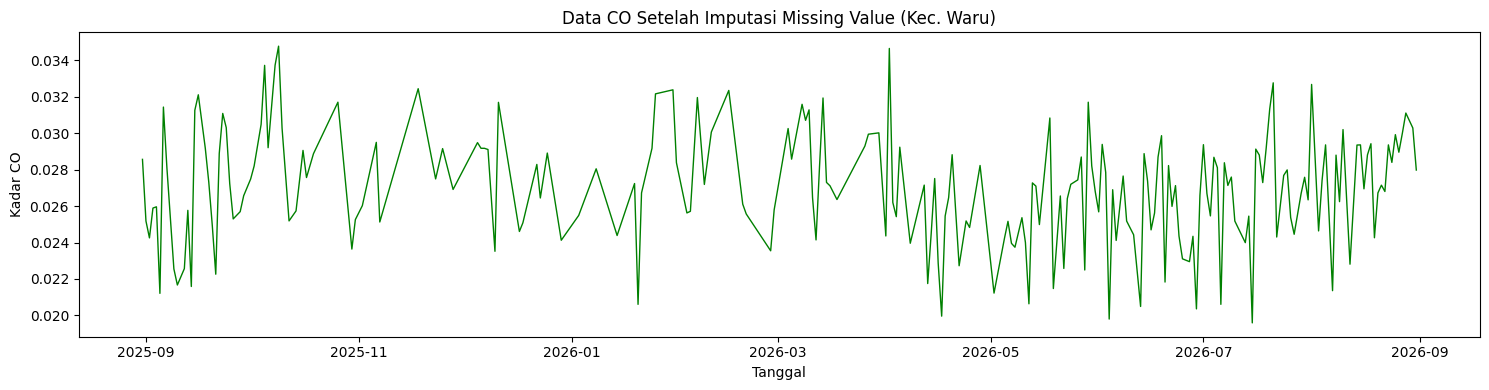

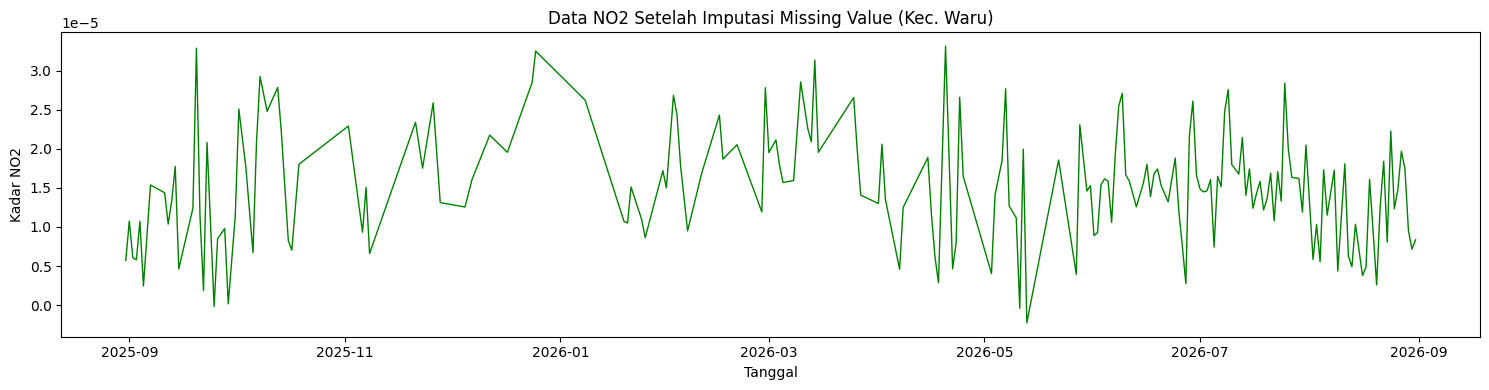

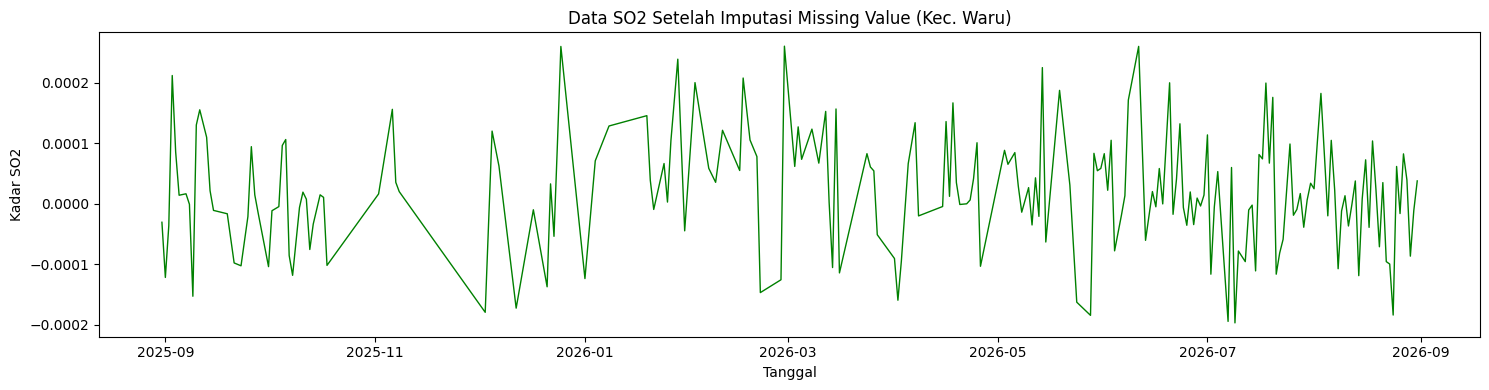

In [ ]:
for pol in POLUTAN_TARGET:
    data_sesudah = df_setelah.copy()

    plt.figure(figsize=(15, 4))
    plt.plot(data_sesudah["tanggal"], data_sesudah[pol], linewidth=1, color="green")
    plt.title(f"Data {pol} Setelah Imputasi Missing Value (Kec. Waru)")
    plt.xlabel("Tanggal")
    plt.ylabel(f"Kadar {pol}")
    plt.tight_layout()
    plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- Perulangan menampilkan data CO, NO2, dan SO2 dari `df_setelah`, yaitu data gabungan (`df_awal` + `sinyal_bersih`) yang sudah melewati deteksi outlier dan imputasi pada bagian 2.
- Kolom `tanggal` tetap memakai tanggal asli sehingga visualisasi tetap mengikuti urutan waktu yang benar (366 hari, 31 Agustus 2025 s.d. 31 Agustus 2026).
- Dibandingkan grafik "sebelum" pada bagian 2.2, garis pada bagian ini sudah kontinu tanpa celah — inilah sinyal bersih (`sinyal_bersih[pol]`) yang selanjutnya masuk ke ekstraksi 68 fitur (bagian 3–5) maupun ke perhitungan manual `hist_mode` dan `fundamental_frequency` (bagian 7).

### 2.4 Perbandingan Missing Value Antar Tahap Preprocessing

Tabel dan diagram batang berikut membandingkan jumlah missing value pada data awal, setelah deteksi outlier, dan setelah imputasi, untuk ketiga polutan sekaligus.

,polutan,missing_awal,missing_setelah_outlier,missing_sesudah_imputasi
0,CO,141,145,0
1,NO2,173,177,0
2,SO2,149,163,0


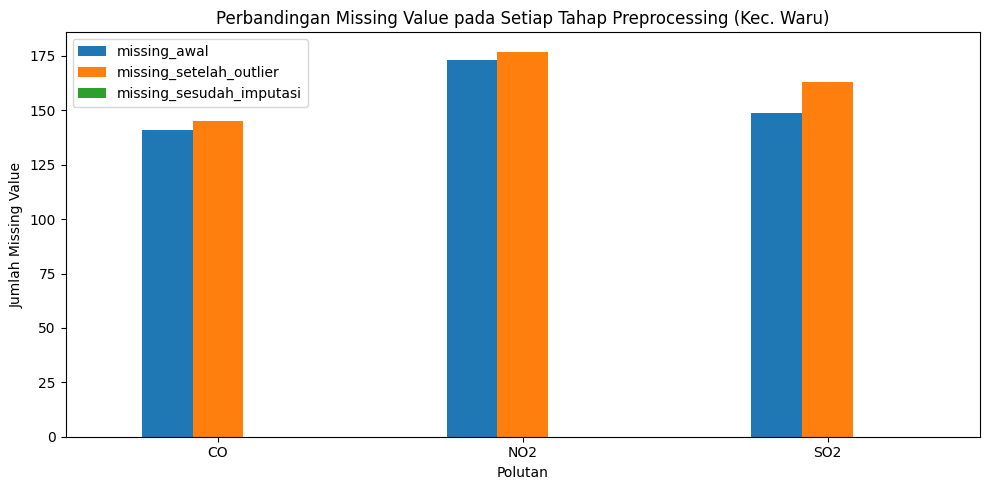

In [ ]:
kolom_tahap_missing = [
    "missing_awal",
    "missing_setelah_outlier",
    "missing_sesudah_imputasi"
]

tabel_missing = ringkasan_missing[["polutan"] + kolom_tahap_missing].copy()
display(tabel_missing)

tabel_missing_plot = tabel_missing.set_index("polutan")
tabel_missing_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Perbandingan Missing Value pada Setiap Tahap Preprocessing (Kec. Waru)")
plt.xlabel("Polutan")
plt.ylabel("Jumlah Missing Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- `tabel_missing` mengambil jumlah missing value pada tiga tahap (sebelum preprocessing, setelah outlier diubah menjadi `NaN`, dan setelah imputasi) untuk CO, NO2, dan SO2.
- Diagram batang memvisualisasikan data yang sama, sehingga penurunan jumlah missing value pada setiap tahap lebih mudah dibandingkan antar polutan: batang "missing_awal" dan "missing_setelah_outlier" pada SO2 terlihat paling tinggi (149 → 163), sedangkan batang "missing_sesudah_imputasi" pada ketiga polutan sama-sama nol.
- Data bersih dari bagian ini (`sinyal_bersih`) selanjutnya dipakai ulang pada tahap ekstraksi fitur di bagian 3, 4, dan 5.

## 3. Ekstraksi 68 Fitur TSFEL — Polutan NO2

### 3.1 Ekstraksi Fitur NO2

In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('data_polutan_waru.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask_outlier = (df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound)
n_outlier = mask_outlier.sum()
print(f"Jumlah outlier terdeteksi (IQR, di luar [{lower_bound:.6f}, {upper_bound:.6f}]): {n_outlier}")
df.loc[mask_outlier, target_pollutant] = np.nan

df_clean = df.set_index('tanggal').interpolate(method='time').ffill().bfill()

# --- Verifikasi: data harus 100% bersih (0 missing, 0 outlier) sebelum lanjut ekstraksi fitur ---
n_missing_setelah_imputasi = df_clean[target_pollutant].isna().sum()
print(f"Sisa nilai kosong setelah imputasi: {n_missing_setelah_imputasi}")
if n_missing_setelah_imputasi == 0:
    print("Data NO2 sudah bersih (0 missing value, 0 outlier tersisa) -> lanjut ke ekstraksi fitur.")
else:
    raise ValueError("Masih ada nilai kosong setelah imputasi -- ekstraksi fitur dibatalkan.")

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_waru_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 173
Jumlah outlier terdeteksi (IQR, di luar [-0.000003, 0.000033]): 4
Sisa nilai kosong setelah imputasi: 0
Data NO2 sudah bersih (0 missing value, 0 outlier tersisa) -> lanjut ke ekstraksi fitur.
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


Penjelasan kode di atas adalah sebagai berikut.

- `data_polutan_waru.csv` dibaca ulang, kolom `tanggal` dikonversi ke datetime dan diurutkan.
- Kolom `NO2` dipaksa numerik (`pd.to_numeric(..., errors="coerce")`); ditemukan 173 nilai tidak valid yang menjadi `NaN`.
- Outlier dideteksi dengan metode IQR (di luar `[Q1-1.5×IQR, Q3+1.5×IQR]` → diubah `NaN`, baris tidak dihapus agar deret tanggal utuh).
- Missing value diisi dengan `interpolate(method="time")`, sisa di ujung data diisi `ffill()`/`bfill()` hingga `df_clean` bebas `NaN`.
- Verifikasi eksplisit: jika `n_missing_setelah_imputasi` tidak 0, proses dihentikan (`raise ValueError`) — data harus benar-benar bersih sebelum ekstraksi.
- Signal bersih diambil sebagai `signal_1d` dengan `fs = 1` (satu observasi per hari).
- `FEATURE_LIST` memuat 68 nama fitur TSFEL (Statistical, Temporal, Spectral, Fractal; rincian di bagian 7.6).
- `extract_one()` memanggil tiap fitur secara generik lewat `inspect.signature` (mendeteksi kebutuhan parameter `fs`), dan `to_scalar()` merata-ratakan fitur yang awalnya menghasilkan banyak nilai agar tetap satu kolom.
- Hasil akhir: satu baris berisi 68 kolom fitur, disimpan sebagai `NO2_waru_TSFEL.csv`.

### 3.2 Membaca dan Memverifikasi Hasil Ekstraksi NO2

In [ ]:
hasil_ekstraksi = pd.read_csv("NO2_waru_TSFEL.csv")

print("Ukuran data:", hasil_ekstraksi.shape)
display(hasil_ekstraksi)

Ukuran data: (1, 68)


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,1.123197e-07,0.005901,5.0,3.077253e-10,168.84489,0.000033,0.000016,0.000016,-0.000002,0.000007,...,0.148818,0.422768,7.722150e-11,0.001353,6.737109e-07,0.00001,2.142401,0.00001,1.046791e-10,6.0


Penjelasan kode di atas adalah sebagai berikut.

- `pd.read_csv("NO2_waru_TSFEL.csv")` membaca kembali berkas hasil ekstraksi fitur yang sudah disimpan sebelumnya, untuk memverifikasi isinya sebelum diunggah ke situs pengumpulan tugas.
- `.shape` menampilkan ukuran datanya — sesuai output, hasilnya `(1, 68)`, artinya 1 baris data dengan 68 kolom fitur, persis sesuai target 68 fitur TSFEL yang diminta.
- `display(hasil_ekstraksi)` menampilkan tabelnya secara langsung di Colab sebagai pengecekan visual, dan seluruh nilai fitur (mis. `abs_energy` ≈ 1,12×10⁻⁷, `calc_mean` ≈ 1,6×10⁻⁵) tampil wajar tanpa nilai kosong maupun tak terhingga.

## 4. Ekstraksi 68 Fitur TSFEL — Polutan CO

### 4.1 Ekstraksi Fitur CO

In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('data_polutan_waru.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)

target_pollutant = 'CO'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('tanggal').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_waru_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 141
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk CO: 68


Penjelasan kode di atas adalah sebagai berikut.

- Langkah deteksi outlier (metode IQR), imputasi missing value (`interpolate(method="time")` + `ffill()`/`bfill()`), dan ekstraksi 68 fitur berjalan persis sama seperti pada NO2, kali ini diterapkan pada kolom `CO`.
- Ditemukan **141 nilai** yang dikonversi menjadi `NaN` pada kolom CO — lebih sedikit dibanding NO2 (173), menunjukkan kualitas data mentah CO untuk Kecamatan Waru sedikit lebih baik.
- Hasil akhir tetap berupa satu baris dengan 68 kolom fitur, disimpan sebagai `CO_waru_TSFEL.csv`.

### 4.2 Membaca dan Memverifikasi Hasil Ekstraksi CO

In [ ]:
hasil_ekstraksi = pd.read_csv("CO_waru_TSFEL.csv")

print("Ukuran data:", hasil_ekstraksi.shape)
display(hasil_ekstraksi)

Ukuran data: (1, 68)


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.272816,9.91139,2.0,0.000747,178.915949,0.034778,0.027158,0.02719,0.019591,0.002805,...,0.134423,0.643926,0.000014,0.677107,0.001578,0.006996,2.139672,0.006794,0.000052,0.0


Penjelasan kode di atas adalah sebagai berikut.

- Sama seperti verifikasi NO2, berkas `CO_waru_TSFEL.csv` dibaca ulang untuk memastikan ukurannya `(1, 68)` dan nilainya wajar.
- Nilai fitur CO secara umum berskala lebih besar dibanding NO2 (mis. `calc_mean` ≈ 0,027 untuk CO, dibanding ≈ 1,6×10⁻⁵ untuk NO2) — hal ini wajar karena satuan/rentang konsentrasi tiap polutan memang berbeda, dan menjadi alasan mengapa standardisasi (z-score) diperlukan sebelum data ketiga polutan ini digabung dan dianalisis bersama pada tahap clustering.

## 5. Ekstraksi 68 Fitur TSFEL — Polutan SO2

### 5.1 Ekstraksi Fitur SO2

In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('data_polutan_waru.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)

target_pollutant = 'SO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('tanggal').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_waru_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 149
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk SO2: 68


Penjelasan kode di atas adalah sebagai berikut.

- Prosedur deteksi outlier, imputasi, dan ekstraksi fitur diterapkan pada kolom `SO2`.
- Ditemukan **149 nilai** yang dikonversi menjadi `NaN` pada kolom SO2 — berada di antara jumlah NO2 (173) dan CO (141).
- Hasil akhir disimpan sebagai `SO2_waru_TSFEL.csv`, kembali berupa satu baris dengan 68 kolom fitur.

### 5.2 Membaca dan Memverifikasi Hasil Ekstraksi SO2

In [ ]:
hasil_ekstraksi = pd.read_csv("SO2_waru_TSFEL.csv")

print("Ukuran data:", hasil_ekstraksi.shape)
display(hasil_ekstraksi)

Ukuran data: (1, 68)


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.000003,0.025229,3.0,9.246593e-09,184.642957,0.000261,0.000011,0.000005,-0.000197,0.000095,...,0.147753,0.159843,1.514829e-08,0.020659,3.775648e-07,0.000138,2.166454,0.000138,1.987629e-08,95.0


Penjelasan kode di atas adalah sebagai berikut.

- Berkas `SO2_waru_TSFEL.csv` dibaca ulang dan dipastikan berukuran `(1, 68)`.
- Nilai fitur SO2 berada pada skala yang berbeda lagi dari NO2 maupun CO (mis. `calc_mean` ≈ 1,1×10⁻⁵), mempertegas perlunya standardisasi sebelum penggabungan tiga polutan pada tahap berikutnya.

## 6. Ringkasan Ekstraksi Fitur 3 Polutan

In [ ]:
import pandas as pd

# Nilai berikut diambil langsung dari output masing-masing sel ekstraksi di atas
ringkasan = pd.DataFrame({
    "polutan": ["NO2", "CO", "SO2"],
    "nilai_kosong_sebelum_imputasi": [173, 141, 149],
    "jumlah_fitur_dihasilkan": [68, 68, 68],
    "berkas_output": ["NO2_waru_TSFEL.csv", "CO_waru_TSFEL.csv", "SO2_waru_TSFEL.csv"],
})
ringkasan


,polutan,nilai_kosong_sebelum_imputasi,jumlah_fitur_dihasilkan,berkas_output
0,NO2,173,68,NO2_waru_TSFEL.csv
1,CO,141,68,CO_waru_TSFEL.csv
2,SO2,149,68,SO2_waru_TSFEL.csv


Penjelasan kode di atas adalah sebagai berikut.

- Tabel `ringkasan` disusun dari angka yang sudah tercetak pada output tiap sel ekstraksi sebelumnya (bukan dihitung ulang), semata-mata untuk menyandingkan hasil ketiga polutan dalam satu tampilan.
- Ketiganya konsisten menghasilkan **68 fitur** sesuai target, dengan jumlah nilai kosong yang berbeda-beda (CO paling sedikit, NO2 paling banyak) — mengindikasikan kualitas data mentah citra satelit sedikit berbeda antar polutan untuk periode dan lokasi yang sama.
- Ketiga berkas (`NO2_waru_TSFEL.csv`, `CO_waru_TSFEL.csv`, `SO2_waru_TSFEL.csv`) inilah yang selanjutnya diunggah ke situs pengumpulan tugas kelompok beserta nama dan kecamatan yang diambil, untuk digabungkan dengan hasil ekstraksi kecamatan lain pada basis data bersama — sebagaimana dibahas pada bagian selanjutnya.

## 7. Konsep Dasar dan Contoh Perhitungan Manual Fitur Bagian Sendiri

Bagian ini melanjutkan notebook sebelumnya mengikuti pembaruan instruksi yaitu:
1. Deskripsi & contoh perhitungan manual fitur (dibuktikan dengan TSFEL) sebelum ekstraksi dilakukan,
2. Ekstraksi fitur dibagi per mahasiswa (lihat `pembagian_fitur_ekstraksi.xlsx`) untuk **3 polutan** (CO, NO2, SO2), bukan hanya NO2.

Data hasil ekstraksi seluruh kelas selanjutnya digabung dan diunggah ke database, lalu direduksi dimensinya dengan PCA dan dicari jumlah cluster K-Means terbaik — dibahas pada notebook **bagian 2**.

Bagian fitur saya **Rian Renaldy** pada tabel pembagian adalah **`fundamental_frequency(signal, fs)`** dan **`hist_mode(signal, nbins)`**.

### 7.1 `hist_mode` (Domain Statistical)
Fitur ini menghitung **modus** dari sinyal melalui pendekatan histogram, karena modus klasik (nilai yang paling sering muncul persis) jarang berguna untuk data kontinu seperti konsentrasi polutan (hampir semua nilai unik). Caranya:
1. Sinyal dibagi ke dalam `nbins` interval (bin) dengan lebar sama, dari nilai minimum sampai maksimum sinyal.
2. Dihitung berapa banyak titik data yang jatuh ke tiap bin.
3. Bin dengan jumlah data terbanyak dianggap mewakili nilai yang paling "umum" muncul, dan **nilai tengah bin tersebut** dijadikan hasil akhir (modus histogram).

### 7.2 `fundamental_frequency` (Domain Spectral)
Fitur ini mencari **frekuensi dominan** yang paling menjelaskan pola periodik dalam sinyal, melalui domain frekuensi (FFT). Caranya:
1. Rata-rata sinyal (komponen DC/offset) dihilangkan terlebih dahulu, karena offset konstan akan muncul sebagai puncak palsu di frekuensi 0.
2. Sinyal ditransformasi ke domain frekuensi menggunakan *Fast Fourier Transform* (FFT), menghasilkan spektrum magnitudo di tiap frekuensi.
3. Dicari puncak-puncak (*peaks*) signifikan pada spektrum tersebut — yaitu yang magnitudonya minimal 30% dari puncak tertinggi (agar noise kecil tidak ikut terhitung).
4. Komponen frekuensi 0 Hz (DC) dibuang, lalu **frekuensi terendah** di antara puncak-puncak signifikan yang tersisa dijadikan frekuensi fundamental.

Kedua fitur ini selanjutnya dihitung manual (rumus + substitusi angka) pada bagian 7.3 dan 7.4 memakai **data polutan asli milik saya**, yaitu deret harian **NO2, CO, dan SO2** Kecamatan Waru pada berkas `data_polutan_waru.csv` (366 hari, 31 Agustus 2025 s.d. 31 Agustus 2026). Data terlebih dahulu dibersihkan dengan langkah yang sama seperti pada bagian 2 (Data Preparation): nilai non-numerik dan outlier IQR diubah menjadi `NaN`, lalu diimputasi dengan interpolasi waktu, sehingga angka yang dihitung manual di sini identik dengan angka yang masuk ke ekstraksi fitur. Dengan $f_s = 1$ (satu observasi per hari) dan $N = 366$, frekuensi pada `fundamental_frequency` berada dalam satuan **siklus per hari**.

### 7.3 Rumus dan Perhitungan Manual — `hist_mode`

**Rumus umum.** Untuk sinyal $x = \{x_1, x_2, \dots, x_N\}$ dan jumlah bin $B$:

$$w = \frac{x_{max} - x_{min}}{B} \qquad \text{(lebar tiap bin)}$$

$$e_k = x_{min} + k \cdot w, \quad k = 0, 1, \dots, B \qquad \text{(batas-batas bin)}$$

$$c_k = \left|\{\, x_i \mid e_k \le x_i < e_{k+1} \,\}\right| \qquad \text{(jumlah data pada bin ke-}k\text{; bin terakhir tertutup sehingga ikut memuat } x_{max}\text{)}$$

$$k^{*} = \underset{k}{\operatorname{argmax}}\ c_k$$

$$\text{hist\_mode} = \frac{e_{k^{*}} + e_{k^{*}+1}}{2}$$

**Langkah perhitungan (berlaku untuk ketiga polutan di bawah, angkanya beda karena rentang nilainya beda):**

1. **Tentukan $x_{min}$ dan $x_{max}$** dari sinyal bersih (366 nilai harian).
2. **Hitung lebar tiap bin** $w = (x_{max}-x_{min})/B$, dengan $B=10$.
3. **Tentukan batas-batas bin** $e_k = x_{min}+k\cdot w$ untuk $k=0,\dots,10$, lalu **hitung $c_k$** yaitu banyaknya data yang jatuh pada tiap bin (bin terakhir ditutup sehingga ikut memuat $x_{max}$).
4. **Cek totalnya**: $\sum_k c_k$ harus sama dengan $N=366$ — bila tidak, ada data yang belum masuk bin manapun.
5. **Cari bin dengan $c_k$ terbanyak** ($k^{*}=\operatorname{argmax}_k c_k$) — inilah rentang nilai yang paling sering muncul.
6. **Hitung `hist_mode`** sebagai titik tengah bin ke-$k^{*}$: $(e_{k^{*}}+e_{k^{*}+1})/2$.

**Data yang dipakai.** Deret harian tiap polutan Kecamatan Waru ($N = 366$ hari) setelah dibersihkan, dengan jumlah bin $B = 10$ (nilai bawaan TSFEL). Angka pada tabel dibulatkan menjadi 5 angka penting untuk tampilan; perhitungan presisi penuh dijalankan pada kode di bagian 7.5.

#### Polutan NO2

- $x_{min} = -2{,}2654 \times 10^{-6}$ dan $x_{max} = 3{,}3120 \times 10^{-5}$
- $w = \dfrac{x_{max} - x_{min}}{10} = \dfrac{3{,}3120 \times 10^{-5} - (-2{,}2654 \times 10^{-6})}{10} = 3{,}5385 \times 10^{-6}$

| $k$ | Rentang bin | $c_k$ | Keterangan |
|---:|:---|---:|:---|
| 0 | $[-2{,}2654 \times 10^{-6},\ 1{,}2731 \times 10^{-6})$ | 5 |  |
| 1 | $[1{,}2731 \times 10^{-6},\ 4{,}8116 \times 10^{-6})$ | 14 |  |
| 2 | $[4{,}8116 \times 10^{-6},\ 8{,}3501 \times 10^{-6})$ | 27 |  |
| 3 | $[8{,}3501 \times 10^{-6},\ 1{,}1889 \times 10^{-5})$ | 44 |  |
| 4 | $[1{,}1889 \times 10^{-5},\ 1{,}5427 \times 10^{-5})$ | **83** | ← terbanyak |
| 5 | $[1{,}5427 \times 10^{-5},\ 1{,}8966 \times 10^{-5})$ | 71 |  |
| 6 | $[1{,}8966 \times 10^{-5},\ 2{,}2504 \times 10^{-5})$ | 62 |  |
| 7 | $[2{,}2504 \times 10^{-5},\ 2{,}6043 \times 10^{-5})$ | 26 |  |
| 8 | $[2{,}6043 \times 10^{-5},\ 2{,}9581 \times 10^{-5})$ | 24 |  |
| 9 | $[2{,}9581 \times 10^{-5},\ 3{,}3120 \times 10^{-5}]$ | 10 |  |

- Cek: $\sum c_k = 366 = N$
- $k^{*} = \underset{k}{\operatorname{argmax}}\ c_k = 4$ (bin ke-4 berisi 83 data)

$$\text{hist\_mode} = \frac{e_{4} + e_{5}}{2} = \frac{1{,}1889 \times 10^{-5} + 1{,}5427 \times 10^{-5}}{2} = \mathbf{1{,}3658 \times 10^{-5}}$$

#### Polutan CO

- $x_{min} = 0{,}019591$ dan $x_{max} = 0{,}034778$
- $w = \dfrac{x_{max} - x_{min}}{10} = \dfrac{0{,}034778 - 0{,}019591}{10} = 0{,}0015187$

| $k$ | Rentang bin | $c_k$ | Keterangan |
|---:|:---|---:|:---|
| 0 | $[0{,}019591,\ 0{,}021110)$ | 8 |  |
| 1 | $[0{,}021110,\ 0{,}022628)$ | 16 |  |
| 2 | $[0{,}022628,\ 0{,}024147)$ | 23 |  |
| 3 | $[0{,}024147,\ 0{,}025666)$ | 64 |  |
| 4 | $[0{,}025666,\ 0{,}027184)$ | 71 |  |
| 5 | $[0{,}027184,\ 0{,}028703)$ | **75** | ← terbanyak |
| 6 | $[0{,}028703,\ 0{,}030222)$ | 57 |  |
| 7 | $[0{,}030222,\ 0{,}031741)$ | 33 |  |
| 8 | $[0{,}031741,\ 0{,}033259)$ | 15 |  |
| 9 | $[0{,}033259,\ 0{,}034778]$ | 4 |  |

- Cek: $\sum c_k = 366 = N$
- $k^{*} = \underset{k}{\operatorname{argmax}}\ c_k = 5$ (bin ke-5 berisi 75 data)

$$\text{hist\_mode} = \frac{e_{5} + e_{6}}{2} = \frac{0{,}027184 + 0{,}028703}{2} = \mathbf{0{,}027944}$$

#### Polutan SO2

- $x_{min} = -1{,}9729 \times 10^{-4}$ dan $x_{max} = 2{,}6082 \times 10^{-4}$
- $w = \dfrac{x_{max} - x_{min}}{10} = \dfrac{2{,}6082 \times 10^{-4} - (-1{,}9729 \times 10^{-4})}{10} = 4{,}5811 \times 10^{-5}$

| $k$ | Rentang bin | $c_k$ | Keterangan |
|---:|:---|---:|:---|
| 0 | $[-1{,}9729 \times 10^{-4},\ -1{,}5148 \times 10^{-4})$ | 15 |  |
| 1 | $[-1{,}5148 \times 10^{-4},\ -1{,}0566 \times 10^{-4})$ | 28 |  |
| 2 | $[-1{,}0566 \times 10^{-4},\ -5{,}9853 \times 10^{-5})$ | 47 |  |
| 3 | $[-5{,}9853 \times 10^{-5},\ -1{,}4042 \times 10^{-5})$ | 54 |  |
| 4 | $[-1{,}4042 \times 10^{-5},\ 3{,}1769 \times 10^{-5})$ | **77** | ← terbanyak |
| 5 | $[3{,}1769 \times 10^{-5},\ 7{,}7580 \times 10^{-5})$ | 46 |  |
| 6 | $[7{,}7580 \times 10^{-5},\ 1{,}2339 \times 10^{-4})$ | 49 |  |
| 7 | $[1{,}2339 \times 10^{-4},\ 1{,}6920 \times 10^{-4})$ | 31 |  |
| 8 | $[1{,}6920 \times 10^{-4},\ 2{,}1501 \times 10^{-4})$ | 13 |  |
| 9 | $[2{,}1501 \times 10^{-4},\ 2{,}6082 \times 10^{-4}]$ | 6 |  |

- Cek: $\sum c_k = 366 = N$
- $k^{*} = \underset{k}{\operatorname{argmax}}\ c_k = 4$ (bin ke-4 berisi 77 data)

$$\text{hist\_mode} = \frac{e_{4} + e_{5}}{2} = \frac{(-1{,}4042 \times 10^{-5}) + 3{,}1769 \times 10^{-5}}{2} = \mathbf{8{,}8632 \times 10^{-6}}$$

Hasil ketiganya akan dibuktikan sama persis dengan `tsfel_features.hist_mode()` pada kode di bagian 7.5.


### 7.4 Rumus dan Perhitungan Manual — `fundamental_frequency`

**Rumus umum.** Untuk sinyal $x = \{x_0, x_1, \dots, x_{N-1}\}$ dengan frekuensi sampling $f_s$:

$$x'_n = x_n - \bar{x}, \qquad \bar{x} = \frac{1}{N}\sum_{n=0}^{N-1} x_n \qquad \text{(DC offset dihilangkan)}$$

$$X_k = \sum_{n=0}^{N-1} x'_n \, e^{-i 2\pi k n / N}, \quad k = 0, 1, \dots, \left\lfloor N/2 \right\rfloor \qquad \text{(FFT / DFT satu sisi)}$$

$$f_k = \frac{k \cdot f_s}{N} \qquad \text{(frekuensi tiap bin } k\text{)}$$

$$T = 0{,}3 \cdot \max_k |X_k| \qquad \text{(ambang deteksi puncak)}$$

$$f_0 = \min\{\, f_k \mid |X_k| \text{ puncak lokal}, \ |X_k| \ge T, \ k \neq 0 \,\}$$

**Langkah perhitungan (berlaku untuk ketiga polutan di bawah):**

1. **Hilangkan komponen DC (rata-rata)**: $x'_n = x_n - \bar{x}$, agar offset konstan tidak muncul sebagai puncak palsu di $k=0$.
2. **Transformasikan ke domain frekuensi** dengan DFT/FFT satu sisi, menghasilkan magnitudo $|X_k|$ untuk $k=0,1,\dots,\lfloor N/2\rfloor$.
3. **Hitung frekuensi tiap bin** $f_k = k\cdot f_s/N$; dengan $f_s=1$ dan $N=366$, $f_k=k/366$ siklus/hari.
4. **Tentukan ambang deteksi puncak** $T = 0{,}3\times\max_k|X_k|$.
5. **Cari seluruh puncak lokal** (titik $|X_k|$ yang lebih tinggi dari kedua tetangganya) dengan $|X_k|\ge T$, lalu **buang $k=0$** (komponen DC).
6. **Ambil puncak dengan frekuensi terendah** di antara puncak-puncak yang tersisa sebagai $k_0$, lalu $f_0=f_{k_0}=k_0/N$ adalah frekuensi fundamentalnya.

**Data yang dipakai.** Deret harian tiap polutan Kecamatan Waru dengan $N = 366$ dan $f_s = 1$ (satu observasi per hari), sehingga $f_k = k/366$ siklus per hari dan DFT satu sisi memiliki 184 komponen ($k = 0, 1, \dots, 183$). Menjumlahkan $366 \times 184$ suku secara tertulis tidak praktis, jadi nilai $|X_k|$ dihitung dengan rumus DFT di atas melalui `np.fft.rfft`; sebagai bukti, satu koefisien (bin $k_0$ yang terpilih) juga dihitung langsung dengan rumus penjumlahan dan hasilnya sama dengan FFT. Angka dibulatkan menjadi 5 angka penting untuk tampilan.

#### Polutan NO2

- Rata-rata (DC offset) $\bar{x} = 1{,}6136 \times 10^{-5}$ → dikurangkan dari seluruh data
- Magnitudo terbesar $\max|X_k| = 6{,}6891 \times 10^{-4}$ pada $k = 1$ (sehingga ambang $T = 0{,}3 \times 6{,}6891 \times 10^{-4} = 2{,}0067 \times 10^{-4}$)
- Puncak lokal dengan $|X_k| \ge T$ (selain $k=0$): **9 buah**. Lima dengan frekuensi terendah:

| $k$ | $f_k = k/366$ (siklus/hari) | $\lvert X_k \rvert$ | Periode $1/f_k$ (hari) |
|---:|---:|---:|---:|
| **1** | **$0{,}0027322$** | **$6{,}6891 \times 10^{-4}$** | **366,0** |
| 4 | $0{,}010929$ | $4{,}6046 \times 10^{-4}$ | 91,5 |
| 9 | $0{,}024590$ | $4{,}3285 \times 10^{-4}$ | 40,7 |
| 16 | $0{,}043716$ | $3{,}4576 \times 10^{-4}$ | 22,9 |
| 23 | $0{,}062842$ | $2{,}6906 \times 10^{-4}$ | 15,9 |

- Puncak dengan frekuensi terendah: $k_0 = 1$. Cek puncak lokal: $|X_{0}| = 3{,}1171 \times 10^{-19} < |X_{1}| = 6{,}6891 \times 10^{-4} > |X_{2}| = 3{,}0254 \times 10^{-4}$
- Hitung langsung dari rumus DFT: $|X_{1}| = \left|\sum_{n=0}^{365} x'_n e^{-i2\pi \cdot 1 \cdot n/366}\right| = 6{,}6891 \times 10^{-4}$ (sama dengan hasil FFT)

$$f_0 = f_{1} = 1 \cdot \frac{f_s}{N} = \frac{1}{366} = \mathbf{0{,}0027322} \text{ siklus/hari} \quad (\text{periode} \approx 366,0 \text{ hari})$$

#### Polutan CO

- Rata-rata (DC offset) $\bar{x} = 0{,}027158$ → dikurangkan dari seluruh data
- Magnitudo terbesar $\max|X_k| = 0{,}21975$ pada $k = 1$ (sehingga ambang $T = 0{,}3 \times 0{,}21975 = 0{,}065926$)
- Puncak lokal dengan $|X_k| \ge T$ (selain $k=0$): **21 buah**. Lima dengan frekuensi terendah:

| $k$ | $f_k = k/366$ (siklus/hari) | $\lvert X_k \rvert$ | Periode $1/f_k$ (hari) |
|---:|---:|---:|---:|
| **1** | **$0{,}0027322$** | **$0{,}21975$** | **366,0** |
| 3 | $0{,}0081967$ | $0{,}13423$ | 122,0 |
| 6 | $0{,}016393$ | $0{,}16072$ | 61,0 |
| 9 | $0{,}024590$ | $0{,}10618$ | 40,7 |
| 13 | $0{,}035519$ | $0{,}084313$ | 28,2 |

- Puncak dengan frekuensi terendah: $k_0 = 1$. Cek puncak lokal: $|X_{0}| = 6{,}7654 \times 10^{-16} < |X_{1}| = 0{,}21975 > |X_{2}| = 0{,}11115$
- Hitung langsung dari rumus DFT: $|X_{1}| = \left|\sum_{n=0}^{365} x'_n e^{-i2\pi \cdot 1 \cdot n/366}\right| = 0{,}21975$ (sama dengan hasil FFT)

$$f_0 = f_{1} = 1 \cdot \frac{f_s}{N} = \frac{1}{366} = \mathbf{0{,}0027322} \text{ siklus/hari} \quad (\text{periode} \approx 366,0 \text{ hari})$$

#### Polutan SO2

- Rata-rata (DC offset) $\bar{x} = 1{,}1283 \times 10^{-5}$ → dikurangkan dari seluruh data
- Magnitudo terbesar $\max|X_k| = 0{,}0056899$ pada $k = 3$ (sehingga ambang $T = 0{,}3 \times 0{,}0056899 = 0{,}0017070$)
- Puncak lokal dengan $|X_k| \ge T$ (selain $k=0$): **26 buah**. Lima dengan frekuensi terendah:

| $k$ | $f_k = k/366$ (siklus/hari) | $\lvert X_k \rvert$ | Periode $1/f_k$ (hari) |
|---:|---:|---:|---:|
| **3** | **$0{,}0081967$** | **$0{,}0056899$** | **122,0** |
| 5 | $0{,}013661$ | $0{,}0032577$ | 73,2 |
| 8 | $0{,}021858$ | $0{,}0040581$ | 45,8 |
| 10 | $0{,}027322$ | $0{,}0026920$ | 36,6 |
| 12 | $0{,}032787$ | $0{,}0051394$ | 30,5 |

- Bin di bawah $k_0$ yang ikut dicek: $|X_1| = 0{,}0053712 \ge T$ tetapi bukan puncak lokal karena $|X_2| = 0{,}0054046$ lebih besar; $|X_2| = 0{,}0054046 \ge T$ tetapi bukan puncak lokal karena $|X_3| = 0{,}0056899$ lebih besar. Keduanya tidak dihitung sebagai puncak
- Puncak dengan frekuensi terendah: $k_0 = 3$. Cek puncak lokal: $|X_{2}| = 0{,}0054046 < |X_{3}| = 0{,}0056899 > |X_{4}| = 0{,}0030562$
- Hitung langsung dari rumus DFT: $|X_{3}| = \left|\sum_{n=0}^{365} x'_n e^{-i2\pi \cdot 3 \cdot n/366}\right| = 0{,}0056899$ (sama dengan hasil FFT)

$$f_0 = f_{3} = 3 \cdot \frac{f_s}{N} = \frac{3}{366} = \mathbf{0{,}0081967} \text{ siklus/hari} \quad (\text{periode} \approx 122,0 \text{ hari})$$

**Ringkasan hasil hitungan manual (data polutan asli):**

| Polutan | `hist_mode` | `fundamental_frequency` (siklus/hari) | Periode (hari) |
|:---|---:|---:|---:|
| NO2 | $1{,}3658 \times 10^{-5}$ | $0{,}0027322$ | 366,0 |
| CO | $0{,}027944$ | $0{,}0027322$ | 366,0 |
| SO2 | $8{,}8632 \times 10^{-6}$ | $0{,}0081967$ | 122,0 |

**Interpretasi.** Pada NO2 dan CO, puncak signifikan terendah jatuh di $k_0 = 1$, yaitu frekuensi terendah yang bisa dibedakan pada data 366 hari (satu siklus penuh selama periode pengamatan). Artinya variasi lambat sepanjang tahun (pola musiman atau tren) mendominasi sinyal keduanya. Pada SO2 puncak terendah ada di $k_0 = 3$ (periode sekitar 122 hari, kira-kira empat bulan), dan SO2 memiliki puncak signifikan paling banyak (26 buah, dibanding 9 pada NO2 dan 21 pada CO), yang menandakan energinya tersebar ke banyak frekuensi. Ketiga hasil ini akan dibuktikan sama persis dengan `tsfel_features.fundamental_frequency()` pada kode di bagian 7.5.


### 7.5 Pembuktian Perhitungan Manual Menggunakan Python dan TSFEL

Hasil hitungan manual pada 1.3 dan 1.4 di atas selanjutnya dijalankan ulang lewat kode Python (bukan dihitung dengan kalkulator) pada **data polutan asli** `data_polutan_waru.csv` untuk ketiga polutan (NO2, CO, SO2), lalu dibandingkan langsung dengan hasil fungsi bawaan `tsfel`, sebagai pembuktian bahwa rumus manual di atas benar-benar merepresentasikan cara kerja fungsi TSFEL yang sebenarnya. Pembuktiannya dipisah per fitur: **1.5.1** persiapan data, **1.5.2** `hist_mode`, **1.5.3** `fundamental_frequency`, dan **1.5.4** ringkasan.


#### 7.5.1 Persiapan: Memuat dan Membersihkan Data

In [ ]:
import numpy as np
import pandas as pd

# ---------- Muat data polutan asli ----------
df = pd.read_csv('data_polutan_waru.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)
print(f"Data dimuat: {df.shape[0]} hari, {df['tanggal'].min().date()} s.d. {df['tanggal'].max().date()}")


def bersihkan_sinyal(df, kolom):
    """Paksa numerik -> outlier IQR jadi NaN -> interpolasi waktu (+ ffill/bfill), persis seperti bagian 2 (Data Preparation)."""
    s = pd.to_numeric(df[kolom], errors='coerce')
    s.index = df['tanggal']
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    s[(s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)] = np.nan
    return s.interpolate(method='time').ffill().bfill().astype(float).values


fs = 1        # satu observasi per hari
nbins = 10    # jumlah bin bawaan hist_mode

# Sinyal bersih tiap polutan (identik dengan sinyal yang masuk ke ekstraksi 68 fitur)
sinyal = {pol: bersihkan_sinyal(df, pol) for pol in ['NO2', 'CO', 'SO2']}
for pol, x in sinyal.items():
    print(f"{pol}: N = {len(x)} hari | min = {x.min():.6e} | maks = {x.max():.6e} | rata-rata = {x.mean():.6e}")


Data dimuat: 366 hari, 2025-08-31 s.d. 2026-08-31
NO2: N = 366 hari | min = -2.265378e-06 | maks = 3.311950e-05 | rata-rata = 1.613594e-05
CO: N = 366 hari | min = 1.959084e-02 | maks = 3.477807e-02 | rata-rata = 2.715755e-02
SO2: N = 366 hari | min = -1.972867e-04 | maks = 2.608241e-04 | rata-rata = 1.128270e-05


Penjelasan kode di atas adalah sebagai berikut.

- Berkas `data_polutan_waru.csv` dibaca, kolom `tanggal` dikonversi ke datetime, lalu data diurutkan berdasarkan tanggal (366 hari, 31 Agustus 2025 s.d. 31 Agustus 2026).
- Fungsi `bersihkan_sinyal()` menerapkan langkah pembersihan yang sama seperti pada bagian ekstraksi 1.1: kolom dipaksa numerik, outlier menurut aturan IQR diubah menjadi `NaN`, kemudian diimputasi dengan `interpolate(method="time")` dan `ffill()`/`bfill()`.
- `fs = 1` menandakan satu observasi per hari, dan `nbins = 10` adalah jumlah bin bawaan `hist_mode`.
- Dictionary `sinyal` menyimpan sinyal bersih NO2, CO, dan SO2 (masing-masing 366 nilai harian), persis sinyal yang masuk ke ekstraksi 68 fitur. Dictionary ini dipakai bersama oleh sel `hist_mode` dan `fundamental_frequency` di bawah, sehingga sel ini harus dijalankan lebih dulu.


#### 7.5.2 Pembuktian `hist_mode`

##### a. Perhitungan Manual

In [ ]:
import numpy as np

manual_hist_mode = {}  # menyimpan hasil manual, dipakai lagi di sel pembanding TSFEL

for pol, x in sinyal.items():
    N = len(x)
    print("=" * 72)
    print(f"hist_mode -- POLUTAN {pol}  (N = {N} hari, nbins = {nbins})  [MANUAL]")
    print("=" * 72)

    x_min, x_max = x.min(), x.max()
    lebar = (x_max - x_min) / nbins                      # w = (x_max - x_min) / B
    batas = x_min + lebar * np.arange(nbins + 1)         # e_k = x_min + k*w
    batas[-1] = x_max
    jumlah = np.array([np.sum((x >= batas[k]) & (x < batas[k + 1])) for k in range(nbins)])
    jumlah[-1] += np.sum(x == x_max)                     # bin terakhir tertutup: ikut memuat x_max
    k_star = int(np.argmax(jumlah))                      # bin dengan data terbanyak
    mode_manual = (batas[k_star] + batas[k_star + 1]) / 2

    print(f"x_min = {x_min:.6e} | x_max = {x_max:.6e} | lebar bin w = {lebar:.6e}")
    print(" k   rentang bin                                  jumlah")
    for k in range(nbins):
        tutup = "]" if k == nbins - 1 else ")"
        tanda = "  <- terbanyak" if k == k_star else ""
        print(f"{k:>2}   [{batas[k]:>14.6e}, {batas[k + 1]:>14.6e}{tutup}   {jumlah[k]:>5}{tanda}")
    print(f"Total data di semua bin = {jumlah.sum()} (harus sama dengan N = {N})")
    print(f"hist_mode manual = ({batas[k_star]:.6e} + {batas[k_star + 1]:.6e}) / 2 = {mode_manual:.6e}\n")

    manual_hist_mode[pol] = {"mode": mode_manual, "jumlah_bin": jumlah}


hist_mode -- POLUTAN NO2  (N = 366 hari, nbins = 10)  [MANUAL]
x_min = -2.265378e-06 | x_max = 3.311950e-05 | lebar bin w = 3.538488e-06
 k   rentang bin                                  jumlah
 0   [ -2.265378e-06,   1.273110e-06)       5
 1   [  1.273110e-06,   4.811598e-06)      14
 2   [  4.811598e-06,   8.350086e-06)      27
 3   [  8.350086e-06,   1.188857e-05)      44
 4   [  1.188857e-05,   1.542706e-05)      83  <- terbanyak
 5   [  1.542706e-05,   1.896555e-05)      71
 6   [  1.896555e-05,   2.250404e-05)      62
 7   [  2.250404e-05,   2.604253e-05)      26
 8   [  2.604253e-05,   2.958102e-05)      24
 9   [  2.958102e-05,   3.311950e-05]      10
Total data di semua bin = 366 (harus sama dengan N = 366)
hist_mode manual = (1.188857e-05 + 1.542706e-05) / 2 = 1.365782e-05

hist_mode -- POLUTAN CO  (N = 366 hari, nbins = 10)  [MANUAL]
x_min = 1.959084e-02 | x_max = 3.477807e-02 | lebar bin w = 1.518723e-03
 k   rentang bin                                  jumlah
 0   [  1.959

Penjelasan kode di atas adalah sebagai berikut.

- Lebar bin `w = (x_max - x_min) / nbins` dan batas bin `e_k = x_min + k·w` dihitung langsung dari rumus, lalu jumlah data tiap bin dihitung dengan perulangan eksplisit. Bin terakhir tertutup, sehingga `jumlah[-1] += np.sum(x == x_max)` menambahkan nilai maksimum yang jatuh tepat di batas atas.
- Bin dengan jumlah data terbanyak dicari dengan `np.argmax`, lalu **titik tengah bin** tersebut diambil sebagai `hist_mode` manual. Total data di semua bin dicek sama dengan N = 366.
- Hasil (`mode`, `jumlah_bin`) disimpan ke `manual_hist_mode` agar bisa dipakai ulang di sel pembanding TSFEL berikutnya, tanpa menghitung ulang.

##### b. Pembanding dengan TSFEL

In [ ]:
import numpy as np
import tsfel.feature_extraction.features as tsfel_features

hasil_hist_mode = {}

for pol, x in sinyal.items():
    print("=" * 72)
    print(f"hist_mode -- POLUTAN {pol}  [PEMBANDING TSFEL]")
    print("=" * 72)

    hist_np, _ = np.histogram(x, bins=nbins)
    cocok_bin = np.array_equal(manual_hist_mode[pol]["jumlah_bin"], hist_np)
    print(f"Jumlah per bin sama dengan np.histogram? {cocok_bin}")

    mode_manual = manual_hist_mode[pol]["mode"]
    mode_tsfel = tsfel_features.hist_mode(x, nbins=nbins)
    cocok = abs(mode_manual - mode_tsfel) < 1e-12

    print(f"hist_mode manual = {mode_manual:.6e}")
    print(f"hist_mode tsfel  = {mode_tsfel:.6e}")
    print(f"Selisih manual vs tsfel: {abs(mode_manual - mode_tsfel):.3e} -> {'COCOK' if cocok else 'BERBEDA'}\n")

    hasil_hist_mode[pol] = {"manual": mode_manual, "tsfel": mode_tsfel, "cocok": cocok}


hist_mode -- POLUTAN NO2  [PEMBANDING TSFEL]
Jumlah per bin sama dengan np.histogram? True
hist_mode manual = 1.365782e-05
hist_mode tsfel  = 1.365782e-05
Selisih manual vs tsfel: 0.000e+00 -> COCOK

hist_mode -- POLUTAN CO  [PEMBANDING TSFEL]
Jumlah per bin sama dengan np.histogram? True
hist_mode manual = 2.794382e-02
hist_mode tsfel  = 2.794382e-02
Selisih manual vs tsfel: 0.000e+00 -> COCOK

hist_mode -- POLUTAN SO2  [PEMBANDING TSFEL]
Jumlah per bin sama dengan np.histogram? True
hist_mode manual = 8.863170e-06
hist_mode tsfel  = 8.863170e-06
Selisih manual vs tsfel: 0.000e+00 -> COCOK



Penjelasan kode di atas adalah sebagai berikut.

- Jumlah data per bin dari perhitungan manual dicek ulang terhadap `np.histogram()` (hasilnya `True`), lalu `hist_mode` manual dibandingkan dengan `tsfel_features.hist_mode()`.
- Hasilnya **identik** untuk ketiga polutan (selisih 0, status **COCOK**): NO2 ≈ 1.3658e-05, CO ≈ 2.7944e-02, dan SO2 ≈ 8.8632e-06 — sama dengan perhitungan manual pada bagian 7.3.
- Hasil (`manual`, `tsfel`, `cocok`) disimpan ke `hasil_hist_mode` untuk dipakai pada Ringkasan Pembuktian (7.5.4).

#### 7.5.3 Pembuktian `fundamental_frequency`

##### a. Perhitungan Manual

In [ ]:
import numpy as np
import scipy.signal

manual_f0 = {}  # menyimpan hasil manual, dipakai lagi di sel pembanding TSFEL

for pol, x in sinyal.items():
    N = len(x)
    print("=" * 72)
    print(f"fundamental_frequency -- POLUTAN {pol}  (N = {N} hari, fs = {fs})  [MANUAL]")
    print("=" * 72)

    x_c = x - x.mean()                                   # hilangkan DC offset
    mag = np.abs(np.fft.rfft(x_c))                       # |X_k|, k = 0..N/2
    freqs = np.arange(len(mag)) * fs / N                 # f_k = k*fs/N
    ambang = 0.3 * mag.max()                             # T = 0,3 * max|X_k|
    puncak = scipy.signal.find_peaks(mag, height=ambang)[0]
    puncak = puncak[puncak != 0]                         # buang komponen DC
    k0 = int(puncak.min())                               # puncak dengan frekuensi terendah
    f0_manual = freqs[k0]
    X_k0 = np.sum(x_c * np.exp(-2j * np.pi * k0 * np.arange(N) / N))   # DFT langsung (rumus penjumlahan)

    print(f"Rata-rata (DC offset) = {x.mean():.6e} -> dihilangkan")
    print(f"Jumlah komponen FFT satu sisi = {len(mag)} (k = 0..{len(mag) - 1}), f_k = k/{N} siklus/hari")
    print(f"Magnitudo maksimum = {mag.max():.6e} pada k = {int(mag.argmax())}  ->  ambang T = 0,3 x maks = {ambang:.6e}")
    print(f"Puncak lokal signifikan (selain k=0): {len(puncak)} buah; lima dengan frekuensi terendah:")
    print("   k      f_k (siklus/hari)      |X_k|            periode (hari)")
    for k in puncak[:5]:
        print(f"{k:>4}   {freqs[k]:>18.6f}   {mag[k]:>14.6e}   {1 / freqs[k]:>10.1f}")
    print(f"Cek puncak lokal k0={k0}: |X_{k0 - 1}| = {mag[k0 - 1]:.6e} < |X_{k0}| = {mag[k0]:.6e} > |X_{k0 + 1}| = {mag[k0 + 1]:.6e}")
    print(f"|X_{k0}| dari rumus DFT langsung = {abs(X_k0):.6e} (FFT: {mag[k0]:.6e})")
    print(f"Frekuensi fundamental manual f0 = k0/N = {k0}/{N} = {f0_manual:.6f} siklus/hari (periode = {1 / f0_manual:.1f} hari)\n")

    manual_f0[pol] = {"f0": f0_manual, "k0": k0}


fundamental_frequency -- POLUTAN NO2  (N = 366 hari, fs = 1)  [MANUAL]
Rata-rata (DC offset) = 1.613594e-05 -> dihilangkan
Jumlah komponen FFT satu sisi = 184 (k = 0..183), f_k = k/366 siklus/hari
Magnitudo maksimum = 6.689070e-04 pada k = 1  ->  ambang T = 0,3 x maks = 2.006721e-04
Puncak lokal signifikan (selain k=0): 9 buah; lima dengan frekuensi terendah:
   k      f_k (siklus/hari)      |X_k|            periode (hari)
   1             0.002732     6.689070e-04        366.0
   4             0.010929     4.604647e-04         91.5
   9             0.024590     4.328519e-04         40.7
  16             0.043716     3.457634e-04         22.9
  23             0.062842     2.690644e-04         15.9
Cek puncak lokal k0=1: |X_0| = 3.252607e-19 < |X_1| = 6.689070e-04 > |X_2| = 3.025375e-04
|X_1| dari rumus DFT langsung = 6.689070e-04 (FFT: 6.689070e-04)
Frekuensi fundamental manual f0 = k0/N = 1/366 = 0.002732 siklus/hari (periode = 366.0 hari)

fundamental_frequency -- POLUTAN CO  (N = 36

Penjelasan kode di atas adalah sebagai berikut.

- Rata-rata sinyal dihilangkan lebih dulu (`x_c = x - x.mean()`), lalu spektrum magnitudo satu sisi dihitung dengan FFT (`np.fft.rfft`), dengan frekuensi tiap bin `f_k = k·fs/N` (satuan siklus per hari).
- Ambang `T = 0,3 × max|X_k|` dipakai pada `scipy.signal.find_peaks` untuk mencari puncak signifikan; komponen k = 0 dibuang, dan puncak dengan **frekuensi terendah** dijadikan frekuensi fundamental manual.
- `|X_k|` pada bin terpilih juga dihitung langsung dari rumus penjumlahan DFT dan hasilnya sama dengan FFT — bukti bahwa FFT hanyalah cara cepat menghitung rumus DFT pada perhitungan manual 7.4.
- Hasil (`f0`, `k0`) disimpan ke `manual_f0` agar bisa dipakai ulang di sel pembanding TSFEL berikutnya.

##### b. Pembanding dengan TSFEL

In [ ]:
import tsfel.feature_extraction.features as tsfel_features

hasil_f0 = {}

for pol, x in sinyal.items():
    print("=" * 72)
    print(f"fundamental_frequency -- POLUTAN {pol}  [PEMBANDING TSFEL]")
    print("=" * 72)

    f0_manual = manual_f0[pol]["f0"]
    k0 = manual_f0[pol]["k0"]
    f0_tsfel = tsfel_features.fundamental_frequency(x, fs)
    cocok = abs(f0_manual - f0_tsfel) < 1e-12

    print(f"f0 manual = {f0_manual:.6f} siklus/hari")
    print(f"f0 tsfel  = {f0_tsfel:.6f} siklus/hari")
    print(f"Selisih manual vs tsfel: {abs(f0_manual - f0_tsfel):.3e} -> {'COCOK' if cocok else 'BERBEDA'}\n")

    hasil_f0[pol] = {"manual": f0_manual, "tsfel": f0_tsfel, "cocok": cocok, "k0": k0, "periode": 1 / f0_manual}


fundamental_frequency -- POLUTAN NO2  [PEMBANDING TSFEL]
f0 manual = 0.002732 siklus/hari
f0 tsfel  = 0.002732 siklus/hari
Selisih manual vs tsfel: 0.000e+00 -> COCOK

fundamental_frequency -- POLUTAN CO  [PEMBANDING TSFEL]
f0 manual = 0.002732 siklus/hari
f0 tsfel  = 0.002732 siklus/hari
Selisih manual vs tsfel: 0.000e+00 -> COCOK

fundamental_frequency -- POLUTAN SO2  [PEMBANDING TSFEL]
f0 manual = 0.008197 siklus/hari
f0 tsfel  = 0.008197 siklus/hari
Selisih manual vs tsfel: 0.000e+00 -> COCOK



Penjelasan kode di atas adalah sebagai berikut.

- Nilai `f0` dan `k0` hasil manual (dari `manual_f0`) dibandingkan langsung dengan `tsfel_features.fundamental_frequency()`, tanpa menghitung ulang FFT.
- Hasilnya **identik** dengan TSFEL untuk ketiga polutan (selisih 0, status **COCOK**): NO2 dan CO ≈ 0.002732 siklus/hari (k = 1, periode 366 hari), SO2 ≈ 0.008197 siklus/hari (k = 3, periode 122 hari).
- Hasil (`manual`, `tsfel`, `cocok`) disimpan ke `hasil_f0` untuk dipakai pada Ringkasan Pembuktian (7.5.4).

#### 7.5.4 Ringkasan Pembuktian

In [ ]:
import pandas as pd

# Tabel 1: hasil perhitungan MANUAL
tabel_manual = pd.DataFrame({
    "polutan": list(sinyal),
    "hist_mode_manual": [hasil_hist_mode[p]["manual"] for p in sinyal],
    "f0_manual": [hasil_f0[p]["manual"] for p in sinyal],
})

# Tabel 2: hasil TSFEL
tabel_tsfel = pd.DataFrame({
    "polutan": list(sinyal),
    "hist_mode_tsfel": [hasil_hist_mode[p]["tsfel"] for p in sinyal],
    "f0_tsfel": [hasil_f0[p]["tsfel"] for p in sinyal],
})

# Tabel 3: status pembuktian (manual == tsfel?)
tabel_status = pd.DataFrame({
    "polutan": list(sinyal),
    "hist_mode_cocok": [hasil_hist_mode[p]["cocok"] for p in sinyal],
    "f0_cocok": [hasil_f0[p]["cocok"] for p in sinyal],
    "status": ["COCOK" if (hasil_hist_mode[p]["cocok"] and hasil_f0[p]["cocok"]) else "BERBEDA" for p in sinyal],
})

print("Tabel 1. Hasil Perhitungan Manual")
print(tabel_manual.to_string(index=False, float_format='{:.6e}'.format))
print()
print("Tabel 2. Hasil TSFEL")
print(tabel_tsfel.to_string(index=False, float_format='{:.6e}'.format))
print()
print("Tabel 3. Status Pembuktian (Manual vs TSFEL)")
print(tabel_status.to_string(index=False))


Tabel 1. Hasil Perhitungan Manual
polutan  hist_mode_manual    f0_manual
    NO2      1.365782e-05 2.732240e-03
     CO      2.794382e-02 2.732240e-03
    SO2      8.863170e-06 8.196721e-03

Tabel 2. Hasil TSFEL
polutan  hist_mode_tsfel     f0_tsfel
    NO2     1.365782e-05 2.732240e-03
     CO     2.794382e-02 2.732240e-03
    SO2     8.863170e-06 8.196721e-03

Tabel 3. Status Pembuktian (Manual vs TSFEL)
polutan  hist_mode_cocok  f0_cocok status
    NO2             True      True  COCOK
     CO             True      True  COCOK
    SO2             True      True  COCOK


Penjelasan kode di atas adalah sebagai berikut.

- Hasil dipecah menjadi tiga tabel agar mudah dibandingkan: **Tabel 1** berisi hasil perhitungan manual (`hist_mode_manual`, `f0_manual`), **Tabel 2** berisi hasil dari `tsfel_features` (`hist_mode_tsfel`, `f0_tsfel`), dan **Tabel 3** berisi status pembuktian per fitur (`hist_mode_cocok`, `f0_cocok`) serta status gabungan.
- Kolom `status` pada Tabel 3 bernilai **COCOK** bila kedua fitur pada polutan tersebut sama persis antara hitungan manual dan TSFEL.
- Seluruh baris berstatus COCOK, sehingga angka pada perhitungan manual 7.3 dan 7.4 terbukti benar dan sama dengan hasil ekstraksi 68 fitur pada bagian 3–5.

### 7.6 Deskripsi Domain TSFEL (68 Fitur)

TSFEL mengelompokkan fitur ke dalam 4 domain resmi: **Statistical**, **Temporal**, **Spectral**, dan **Fractal**. Total fitur yang diekstraksi pada kode di atas berjumlah **68 fitur (21 + 15 + 26 + 6)**. Di dalam tiap domain, fitur diurutkan sama seperti `FEATURE_LIST`. Tanda `*` pada nama fitur menandakan fitur yang aslinya menghasilkan beberapa nilai sekaligus (lihat catatan di akhir bagian ini). Kolom **Hasil (NO2)** diambil dari baris **Rian Renaldy (Waru, Pamekasan)** pada `ekstraksi_fitur_no2.csv`.

#### 7.6.1 Domain Statistical (21 fitur)
Mengukur karakteristik distribusi nilai sinyal, tanpa memperhatikan urutan waktu.

| No | Fitur | Deskripsi | Rumus | Hasil (NO2) |
|---:|:---|:---|:---|---:|
| 1 | `abs_energy` | Energi absolut sinyal, yaitu jumlah kuadrat seluruh nilai (Σx²). Nilainya sangat sensitif terhadap skala konsentrasi dan panjang deret. | $E=\displaystyle\sum_{n=1}^{N}x_n^2$ | 1.12320e-07 |
| 2 | `average_power` | Daya rata-rata sinyal, yaitu jumlah kuadrat nilai dibagi rentang waktu sinyal (Σx² / durasi). | $P=\dfrac{\sum_{n=1}^{N}x_n^2}{N/f_s}=\dfrac{f_s}{N}\displaystyle\sum_{n=1}^{N}x_n^2$ | 3.07725e-10 |
| 3 | `calc_max` | Nilai maksimum sinyal. | $x_{max}=\max(x_1,\dots,x_N)$ | 3.31195e-05 |
| 4 | `calc_mean` | Nilai rata-rata sinyal. | $\bar{x}=\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}x_n$ | 1.61359e-05 |
| 5 | `calc_median` | Nilai tengah (median) sinyal; lebih tahan terhadap outlier dibanding rata-rata. | $\tilde{x}=\text{median}(x_1,\dots,x_N)$ | 1.58690e-05 |
| 6 | `calc_min` | Nilai minimum sinyal. | $x_{min}=\min(x_1,\dots,x_N)$ | -2.26538e-06 |
| 7 | `calc_std` | Simpangan baku (standar deviasi) populasi sinyal; ukuran sebaran nilai di sekitar rata-rata. | $\sigma=\sqrt{\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}(x_n-\bar{x})^2}$ | 6.82026e-06 |
| 8 | `calc_var` | Variansi sinyal, yaitu kuadrat simpangan baku. | $\sigma^2=\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}(x_n-\bar{x})^2$ | 4.65159e-11 |
| 9 | `ecdf`* | Nilai *Empirical Cumulative Distribution Function* (ECDF) pada 10 titik pertama (d = 10). | $\hat{F}(x)=\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}\mathbb{1}[x_n\le x]$, dirata-ratakan pada $d=10$ titik pertama | 1.50273e-02 |
| 10 | `ecdf_percentile`* | Nilai sinyal pada persentil ke-20 dan ke-80 berdasarkan ECDF. | $x_p=\hat{F}^{-1}(p)$, untuk $p=0{,}2$ dan $p=0{,}8$ | 1.59290e-05 |
| 11 | `ecdf_percentile_count`* | Jumlah sampel yang nilainya berada pada atau di bawah persentil ke-20 dan ke-80 ECDF. | $c_p=\left\vert{}\{x_n:x_n\le x_p\}\right\vert{}$, untuk $p=0{,}2$ dan $p=0{,}8$ | 1.82500e+02 |
| 12 | `ecdf_slope` | Kemiringan ECDF antara persentil ke-50 dan ke-75, yaitu (0,75 − 0,5) / (x₇₅ − x₅₀). Bernilai tak hingga (inf) jika sinyal konstan. | $m=\dfrac{0{,}75-0{,}5}{x_{75}-x_{50}}$ | 5.42400e+04 |
| 13 | `entropy` | Entropi Shannon dari distribusi frekuensi nilai unik sinyal, dinormalisasi dengan log₂(N). Bernilai 0 jika semua nilai sama dan mendekati 1 jika hampir semua nilai unik. | $H=\dfrac{-\sum_i p_i\log_2 p_i}{\log_2 N}$, $p_i=$ frekuensi relatif nilai unik ke-$i$ | 1.00000e+00 |
| 14 | `hist_mode` | Modus melalui histogram 10 bin: titik tengah bin yang berisi data paling banyak. | $w=\dfrac{x_{max}-x_{min}}{10}$; $e_k=x_{min}+kw$; $\text{hist\_mode}=\dfrac{e_{k^*}+e_{k^*+1}}{2}$, dengan $k^*=\arg\max_k c_k$ | 1.36578e-05 |
| 15 | `interq_range` | Rentang antarkuartil, yaitu Q3 − Q1; ukuran sebaran 50% data tengah. | $IQR=Q_3-Q_1$ | 8.58076e-06 |
| 16 | `kurtosis` | Kurtosis (*excess*, bernilai 0 untuk distribusi normal). Nilai tinggi berarti ekor distribusi berat, banyak nilai ekstrem. | $\text{Kurt}=\dfrac{\frac{1}{N}\sum_{n=1}^{N}(x_n-\bar{x})^4}{\left(\frac{1}{N}\sum_{n=1}^{N}(x_n-\bar{x})^2\right)^2}-3$ | -1.87061e-01 |
| 17 | `mean_abs_deviation` | Rata-rata selisih mutlak tiap nilai terhadap rata-ratanya. | $\text{MAD}=\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}\left\vert{}x_n-\bar{x}\right\vert{}$ | 5.40888e-06 |
| 18 | `median_abs_deviation` | Median dari selisih mutlak tiap nilai terhadap mediannya; ukuran sebaran yang tahan outlier. | $\text{MedAD}=\text{median}\left(\left\vert{}x_n-\tilde{x}\right\vert{}\right)$ | 4.37358e-06 |
| 19 | `pk_pk_distance` | Jarak puncak ke puncak, yaitu nilai maksimum − nilai minimum (rentang total). | $d_{pp}=x_{max}-x_{min}$ | 3.53849e-05 |
| 20 | `rms` | *Root Mean Square*: akar dari rata-rata kuadrat nilai sinyal; ukuran besar sinyal secara keseluruhan. | $\text{RMS}=\sqrt{\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}x_n^2}$ | 1.75181e-05 |
| 21 | `skewness` | Kemencengan distribusi. Positif berarti ekor panjang di sisi nilai besar, negatif berarti di sisi nilai kecil. | $\text{Skew}=\dfrac{\frac{1}{N}\sum_{n=1}^{N}(x_n-\bar{x})^3}{\left(\frac{1}{N}\sum_{n=1}^{N}(x_n-\bar{x})^2\right)^{3/2}}$ | 6.34953e-02 |

#### 7.6.2 Domain Temporal (15 fitur)
Mengukur pola perubahan sinyal terhadap waktu (urutan data diperhatikan).

| No | Fitur | Deskripsi | Rumus | Hasil (NO2) |
|---:|:---|:---|:---|---:|
| 1 | `auc` | Luas area di bawah kurva sinyal terhadap waktu, dihitung dengan aturan trapesium (*trapezoid rule*). | $\text{AUC}=\displaystyle\sum_{n=1}^{N-1}\dfrac{x_n+x_{n+1}}{2}\Delta t$, $\Delta t=1/f_s$ | 5.90093e-03 |
| 2 | `autocorr` | Lag (jeda) pertama saat fungsi autokorelasi turun di bawah 1/e ≈ 0,368. Menunjukkan seberapa lama nilai sinyal masih "mengingat" nilai sebelumnya (satuan: hari). | $r(\tau)=\dfrac{\sum_n(x_n-\bar{x})(x_{n+\tau}-\bar{x})}{\sum_n(x_n-\bar{x})^2}$; ambil $\tau$ terkecil dengan $r(\tau)<1/e$ | 5.00000e+00 |
| 3 | `calc_centroid` | Titik berat energi sinyal pada sumbu waktu, Σ(t·x²) / Σ(x²). Menunjukkan pada bagian waktu mana (awal, tengah, atau akhir periode) energi sinyal terkonsentrasi. | $C=\dfrac{\sum_{n} t_n\,x_n^2}{\sum_n x_n^2}$, $t_n=n/f_s$ | 1.68845e+02 |
| 4 | `distance` | Panjang lintasan kurva sinyal, Σ√(1 + Δx²), yaitu jarak total yang ditempuh sinyal antar titik berurutan. | $D=\displaystyle\sum_{n=1}^{N-1}\sqrt{1+(x_{n+1}-x_n)^2}$ | 3.65000e+02 |
| 5 | `lempel_ziv` | Kompleksitas Lempel-Ziv: sinyal diubah menjadi biner (di atas atau di bawah rata-rata), lalu dihitung banyaknya pola berbeda dan dinormalisasi panjang sinyal. Rendah berarti teratur, tinggi berarti acak. | $b_n=\mathbb{1}[x_n>\bar{x}]$; $\text{LZC}=\dfrac{c(n)\,\log_2 n}{n}$, $c(n)=$ jumlah pola berbeda pada $b$ | 1.80328e-01 |
| 6 | `mean_abs_diff` | Rata-rata selisih mutlak antara dua titik berurutan; menggambarkan besar perubahan rata-rata dari hari ke hari. | $\dfrac{1}{N-1}\displaystyle\sum_{n=1}^{N-1}\left\vert{}x_{n+1}-x_n\right\vert{}$ | 3.70658e-06 |
| 7 | `mean_diff` | Rata-rata selisih antara dua titik berurutan (bertanda). Positif berarti sinyal cenderung naik dan negatif berarti cenderung turun. | $\dfrac{1}{N-1}\displaystyle\sum_{n=1}^{N-1}(x_{n+1}-x_n)$ | 7.22393e-09 |
| 8 | `median_abs_diff` | Median dari selisih mutlak antara dua titik berurutan. | $\text{median}\left(\left\vert{}x_{n+1}-x_n\right\vert{}\right)$ | 1.84788e-06 |
| 9 | `median_diff` | Median dari selisih (bertanda) antara dua titik berurutan. | $\text{median}\left(x_{n+1}-x_n\right)$ | 8.35470e-08 |
| 10 | `negative_turning` | Jumlah titik balik negatif, yaitu lembah lokal saat sinyal turun lalu naik. | Jumlah $n$ dengan $d_{n-1}<0$ dan $d_n>0$, $d_n=x_{n+1}-x_n$ | 6.00000e+01 |
| 11 | `neighbourhood_peaks` | Jumlah puncak lokal yang lebih tinggi daripada 10 tetangga di kiri dan 10 di kanannya (puncak yang menonjol). | Jumlah $n$ dengan $x_n>x_{n\pm i}\ \forall i=1,\dots,10$ | 1.60000e+01 |
| 12 | `positive_turning` | Jumlah titik balik positif, yaitu puncak lokal saat sinyal naik lalu turun. | Jumlah $n$ dengan $d_{n-1}>0$ dan $d_n<0$, $d_n=x_{n+1}-x_n$ | 6.00000e+01 |
| 13 | `slope` | Kemiringan garis regresi linear terhadap waktu; menggambarkan tren keseluruhan (positif naik, negatif turun). | $m=\dfrac{N\sum t_n x_n-\sum t_n\sum x_n}{N\sum t_n^2-\left(\sum t_n\right)^2}$ | -9.95465e-09 |
| 14 | `sum_abs_diff` | Jumlah seluruh selisih mutlak antara titik berurutan; total variasi (naik-turunnya) sinyal. | $\displaystyle\sum_{n=1}^{N-1}\left\vert{}x_{n+1}-x_n\right\vert{}$ | 1.35290e-03 |
| 15 | `zero_cross` | Jumlah persilangan nol (sinyal berganti tanda positif ke negatif atau sebaliknya). Bernilai 0 jika seluruh nilai bertanda sama. | Jumlah $n$ dengan $x_n\cdot x_{n+1}<0$ | 6.00000e+00 |

#### 7.6.3 Domain Spectral (26 fitur)
Mengubah sinyal ke ranah frekuensi (lewat FFT atau wavelet) lalu mengukur karakteristiknya di sana. $X_k$ = magnitudo FFT sinyal (setelah rata-rata dibuang), $f_k=k\cdot f_s/N$.

| No | Fitur | Deskripsi | Rumus | Hasil (NO2) |
|---:|:---|:---|:---|---:|
| 1 | `fundamental_frequency` | Frekuensi dasar: rata-rata dibuang, FFT dihitung, lalu diambil puncak spektrum berfrekuensi terendah yang tingginya minimal 30% dari puncak tertinggi (selain 0 Hz). Satuan: siklus per hari. | $T=0{,}3\max_k\left\vert{}X_k\right\vert{}$; $f_0=\min\{f_k:\left\vert{}X_k\right\vert{}\ge T,\,k\neq 0\}$ | 2.73224e-03 |
| 2 | `human_range_energy` | Rasio energi spektrum pada pita 0,6–2,5 Hz terhadap total energi (dirancang untuk sinyal gerak manusia). Dengan fs = 1 (harian) frekuensi Nyquist hanya 0,5 sehingga pita ini di luar jangkauan dan nilainya 0. | $\dfrac{\sum_{f_k\in[0{,}6;\,2{,}5]}\left\vert{}X_k\right\vert{}^2}{\sum_k\left\vert{}X_k\right\vert{}^2}$ | 0.00000e+00 |
| 3 | `lpcc`* | *Linear Prediction Cepstral Coefficients*: 12 koefisien cepstral dari model prediksi linear, yang menggambarkan bentuk selubung (*envelope*) spektrum. | Koefisien LPC $a_p$ dari persamaan Yule-Walker, lalu $c_m=a_m+\sum_{k=1}^{m-1}\frac{k}{m}c_k a_{m-k}$ | 6.88733e-01 |
| 4 | `max_frequency` | Frekuensi tempat kumulatif magnitudo FFT melewati 95% dari totalnya. | $f=\min\left\{f_k:\sum_{f_j\le f_k}\left\vert{}X_j\right\vert{}\ge 0{,}95\sum_j\left\vert{}X_j\right\vert{}\right\}$ | 4.34426e-01 |
| 5 | `max_power_spectrum` | Nilai maksimum *power spectral density* (metode Welch) dari sinyal yang dinormalisasi dengan simpangan bakunya. | $\max_k\ \text{PSD}_{\text{Welch}}\!\left(x/\sigma_x\right)_k$ | 4.10562e+01 |
| 6 | `median_frequency` | Frekuensi tempat kumulatif magnitudo FFT mencapai 50% dari totalnya. | $f=\min\left\{f_k:\sum_{f_j\le f_k}\left\vert{}X_j\right\vert{}\ge 0{,}5\sum_j\left\vert{}X_j\right\vert{}\right\}$ | 7.37705e-02 |
| 7 | `mfcc`* | *Mel-Frequency Cepstral Coefficients*: 12 koefisien yang menggambarkan daya spektrum pada skala frekuensi Mel (lazim dipakai pada pengolahan suara). | $m=2595\log_{10}\!\left(1+\dfrac{f}{700}\right)$; $c_k=\displaystyle\sum_{i=1}^{M}\log(S_i)\cos\!\left[\dfrac{\pi k}{M}\left(i-0{,}5\right)\right]$ | 2.64839e+01 |
| 8 | `power_bandwidth` | Lebar pita frekuensi yang memuat 95% daya sinyal (berdasarkan *power spectral density*). | $BW=f_{97{,}5\%}-f_{2{,}5\%}$ dari kumulatif PSD | 3.22404e-01 |
| 9 | `spectral_centroid` | Pusat massa spektrum, yaitu rata-rata frekuensi yang dibobot magnitudo FFT. Nilai rendah berarti energi didominasi variasi lambat. | $C=\dfrac{\sum_k f_k\left\vert{}X_k\right\vert{}}{\sum_k\left\vert{}X_k\right\vert{}}$ | 1.35843e-01 |
| 10 | `spectral_decrease` | Tingkat penurunan amplitudo spektrum menuju frekuensi yang lebih tinggi. | $SD=\dfrac{\sum_{k=2}^{K}\frac{\left\vert{}X_k\right\vert{}-\left\vert{}X_1\right\vert{}}{k-1}}{\sum_{k=2}^{K}\left\vert{}X_k\right\vert{}}$ | -1.84868e+00 |
| 11 | `spectral_distance` | Jarak antara kumulatif magnitudo FFT dan garis lurus yang menghubungkan titik awal dan akhirnya; menilai keseragaman sebaran energi spektrum. | $\displaystyle\sum_k\left[\text{cumsum}(\left\vert{}X\right\vert{})_k-\text{garis lurus}_k\right]$ | -9.95753e-01 |
| 12 | `spectral_entropy` | Entropi distribusi daya spektrum (dinormalisasi). Rendah berarti energi terpusat pada beberapa frekuensi (periodik), tinggi berarti tersebar merata (mirip noise). | $H=\dfrac{-\sum_k p_k\log_2 p_k}{\log_2 K}$, $p_k=\dfrac{\left|X_k\right|^2}{\sum_k\left|X_k\right|^2}$ | 7.70757e-01 |
| 13 | `spectral_kurtosis` | Kelancipan (*peakedness*) distribusi spektrum di sekitar rata-ratanya. | $\dfrac{\sum_k(f_k-C)^4\left\vert{}X_k\right\vert{}}{\left(\sum_k(f_k-C)^2\left\vert{}X_k\right\vert{}/\sum_k\left\vert{}X_k\right\vert{}\right)^2\sum_k\left\vert{}X_k\right\vert{}}$ | 2.47154e+00 |
| 14 | `spectral_positive_turning` | Jumlah titik balik positif (puncak lokal) pada magnitudo spektrum FFT. | Jumlah $k$ dengan $\left\vert{}X_{k-1}\right\vert{}<\left\vert{}X_k\right\vert{}>\left\vert{}X_{k+1}\right\vert{}$ | 5.60000e+01 |
| 15 | `spectral_roll_off` | Frekuensi yang di bawahnya terkandung 95% magnitudo spektrum. | $f=\min\left\{f_k:\sum_{f_j\le f_k}\left\vert{}X_j\right\vert{}\ge 0{,}95\sum_j\left\vert{}X_j\right\vert{}\right\}$ | 4.34426e-01 |
| 16 | `spectral_roll_on` | Frekuensi yang di bawahnya terkandung 5% magnitudo spektrum. | $f=\min\left\{f_k:\sum_{f_j\le f_k}\left\vert{}X_j\right\vert{}\ge 0{,}05\sum_j\left\vert{}X_j\right\vert{}\right\}$ | 0.00000e+00 |
| 17 | `spectral_skewness` | Ketidaksimetrisan (*asymmetry*) distribusi spektrum di sekitar rata-ratanya. | $\dfrac{\sum_k(f_k-C)^3\left\vert{}X_k\right\vert{}}{\left(\sum_k(f_k-C)^2\left\vert{}X_k\right\vert{}/\sum_k\left\vert{}X_k\right\vert{}\right)^{3/2}\sum_k\left\vert{}X_k\right\vert{}}$ | 8.63513e-01 |
| 18 | `spectral_slope` | Kemiringan dari spektrum daya yang dihitung menggunakan regresi linear amplitudo spektrum terhadap frekuensi (aFFT = m·f + b); menunjukkan apakah energi lebih banyak di frekuensi rendah atau tinggi. | $\left\vert{}X_k\right\vert{}=m f_k+b$ (regresi linear least-squares) | -2.94583e-02 |
| 19 | `spectral_spread` | Sebaran spektrum di sekitar *spectral centroid* (simpangan baku frekuensi yang dibobot magnitudo). | $S=\sqrt{\dfrac{\sum_k(f_k-C)^2\left\vert{}X_k\right\vert{}}{\sum_k\left\vert{}X_k\right\vert{}}}$ | 1.48818e-01 |
| 20 | `spectral_variation` | Variasi spektrum: 1 dikurangi korelasi silang ternormalisasi antara dua bagian spektrum yang berurutan. | $1-\dfrac{\sum_k X_k^{(1)}X_k^{(2)}}{\sqrt{\sum_k\left(X_k^{(1)}\right)^2}\sqrt{\sum_k\left(X_k^{(2)}\right)^2}}$ | 4.22768e-01 |
| 21 | `spectrogram_mean_coeff`* | Rata-rata *power spectral density* tiap bin frekuensi dari spektrogram sinyal (32 bin). | $\overline{S}_b=\dfrac{1}{T}\displaystyle\sum_{t=1}^{T}\left\vert{}\text{STFT}(x)_{b,t}\right\vert{}^2$, untuk 32 bin $b$ | 7.72214e-11 |
| 22 | `wavelet_abs_mean`* | Nilai mutlak dari rata-rata koefisien *Continuous Wavelet Transform* (wavelet *Mexican hat*) pada tiap skala (9 skala). | $\left\vert{}\dfrac{1}{N}\displaystyle\sum_{n=1}^{N} C(a, n)\right\vert{}$, untuk 9 skala $a$ | - |$\left|\overline{W_s}\right|=\left|\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}W_{s,n}\right|$, untuk skala $s=1,\dots,9$ | 6.73711e-07 |
| 23 | `wavelet_energy`* | Energi (akar rata-rata kuadrat) koefisien CWT pada tiap skala (9 skala). | $E_s=\sqrt{\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}W_{s,n}^2}$ | 9.84739e-06 |
| 24 | `wavelet_entropy` | Entropi Shannon dari distribusi energi koefisien CWT antar skala. | $H=-\displaystyle\sum_{s=1}^{9}p_s\log_2 p_s$, $p_s=\dfrac{E_s}{\sum_{s'}E_{s'}}$ | 2.14240e+00 |
| 25 | `wavelet_std`* | Simpangan baku koefisien CWT pada tiap skala (9 skala). | $\sigma_s=\sqrt{\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}\left(W_{s,n}-\overline{W_s}\right)^2}$ | 9.81985e-06 |
| 26 | `wavelet_var`* | Variansi koefisien CWT pada tiap skala (9 skala). | $\sigma_s^2=\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}\left(W_{s,n}-\overline{W_s}\right)^2$ | 1.04679e-10 |

#### 7.6.4 Domain Fractal / Kompleksitas (6 fitur)
Mengukur kompleksitas dan sifat "memori jangka panjang" sinyal.

| No | Fitur | Deskripsi | Rumus | Hasil (NO2) |
|---:|:---|:---|:---|---:|
| 1 | `dfa` | *Detrended Fluctuation Analysis*: eksponen skala α dari hubungan fluktuasi sinyal terhadap ukuran jendela. α ≈ 0,5 berarti acak (tanpa korelasi), α > 0,5 berarti ada korelasi jangka panjang (persisten). | $F(n)\propto n^{\alpha}$; $\alpha$ = kemiringan regresi $\log F(n)$ terhadap $\log n$ | 9.30418e-01 |
| 2 | `higuchi_fractal_dimension` | Dimensi fraktal metode Higuchi, ukuran kekasaran kurva. Nilai ≈ 1 berarti kurva mulus dan mendekati 2 berarti sangat tidak beraturan. | $L(k)\propto k^{-D}$; $D$ = kemiringan regresi $\log L(k)$ terhadap $\log(1/k)$ | 1.83525e+00 |
| 3 | `hurst_exponent` | Eksponen Hurst dari analisis *rescaled range* (R/S). H ≈ 0,5 berarti acak, H > 0,5 berarti tren cenderung berlanjut (persisten), H < 0,5 berarti cenderung berbalik arah. | $E\!\left[\dfrac{R(n)}{S(n)}\right]=Cn^{H}$; $H$ = kemiringan regresi $\log(R/S)$ terhadap $\log n$ | 8.00332e-01 |
| 4 | `maximum_fractal_length` | *Maximum Fractal Length*: panjang kurva rata-rata pada skala terkecil, diperoleh dari plot log-log metode Higuchi. | Nilai $\log L(k)$ pada $k=1$ dari regresi Higuchi di atas | -2.78408e+00 |
| 5 | `mse` | *Multiscale Entropy*: entropi sampel (*sample entropy*) pada berbagai skala waktu lalu dirata-ratakan; mengukur kompleksitas sinyal pada banyak skala. | $\text{MSE}=\dfrac{1}{\tau_{max}}\displaystyle\sum_{\tau=1}^{\tau_{max}}\text{SampEn}\!\left(y^{(\tau)}\right)$, $y^{(\tau)}$ = sinyal *coarse-grained* skala $\tau$ | 8.29390e-01 |
| 6 | `petrosian_fractal_dimension` | Dimensi fraktal Petrosian: estimasi cepat kompleksitas sinyal berdasarkan banyaknya perubahan tanda pada selisih sinyal. | $D=\dfrac{\log_{10}N}{\log_{10}N+\log_{10}\!\left(\dfrac{N}{N+0{,}4N_\delta}\right)}$, $N_\delta$ = jumlah perubahan tanda pada $\Delta x$ | 1.02132e+00 |

**Catatan membaca tabel:**

- Fitur bertanda `*` aslinya menghasilkan **beberapa nilai** sekaligus: `ecdf` (10), `ecdf_percentile` (2), `ecdf_percentile_count` (2), `lpcc` (12), `mfcc` (12), `spectrogram_mean_coeff` (32), serta `wavelet_abs_mean`, `wavelet_energy`, `wavelet_std`, dan `wavelet_var` (masing-masing 9). Pada notebook ini nilai-nilai tersebut **dirata-ratakan** oleh fungsi `to_scalar()` sehingga tiap fitur tetap menjadi satu kolom (total 68 kolom per polutan). Rumus di atas ditulis untuk satu nilai representatif sebelum dirata-ratakan.
- Frekuensi sampling yang dipakai adalah `fs = 1` (satu observasi per hari), sehingga fitur berdomain frekuensi (mis. `fundamental_frequency`, `median_frequency`, `spectral_roll_off`) berada dalam satuan **siklus per hari** dengan batas atas 0,5 (frekuensi Nyquist), sedangkan fitur berdomain waktu (mis. `autocorr`, `calc_centroid`) berada dalam satuan **hari**.
- `human_range_energy` pada data harian selalu bernilai 0 karena pita 0,6–2,5 Hz berada di atas frekuensi Nyquist (0,5). Hal ini sifat perhitungannya, bukan kesalahan ekstraksi.
- Fitur berbasis energi atau daya (`abs_energy`, `average_power`, `auc`, `max_power_spectrum`, dan sejenisnya) bergantung langsung pada skala konsentrasi polutan, sehingga nilainya bisa berbeda berorde-orde antar polutan dan antar kecamatan. Inilah yang membuat standardisasi diperlukan sebelum PCA dan K-Means.
- Kolom **Hasil (NO2)** adalah nilai fitur NO2 milik **Rian Renaldy (Waru, Pamekasan)**, diambil langsung dari `ekstraksi_fitur_no2.csv`, bukan angka ilustrasi.
